# Regression Discontinuity Design

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import re
import math
from rdd import rdd
import rddensity
from rdrobust import rdrobust
from statsmodels.nonparametric.kde import KDEUnivariate
from scipy import stats
from scipy.stats import norm

sns.set_theme(style='whitegrid', context='notebook')


## data preparation

In [3]:
df = pd.read_parquet('../cleaned_datasets/resale_with_all_features.parquet')
df.columns

Index(['month', 'year', 'town', 'flat_type', 'storey_range', 'floor_area_sqm',
       'flat_model', 'remaining_lease', 'geometry', 'postal_code',
       'resale_price', 'num_schools_1km', 'num_schools_2km',
       'num_tier1_schools_1km', 'num_tier1_schools_2km',
       'num_tier2_schools_1km', 'num_tier2_schools_2km',
       'nearest_tier1_primary_school_dist_m', 'nearest_primary_school_dist_m',
       'nearest_normal_primary_school_dist_m', 'num_unique_mrt_500m',
       'num_unique_mrt_1km', 'num_unique_mrt_lines_500m',
       'num_unique_mrt_lines_1km', 'walking_dist_mrt_m', 'num_busstops_500m',
       'num_busstops_1km', 'walking_dist_busstop_m', 'num_unique_hawker_500m',
       'num_unique_hawker_1km', 'walking_dist_hawker_m', 'num_malls_1km',
       'num_malls_2km', 'walking_dist_mall_m', 'dist_cbd_m'],
      dtype='object')

In [4]:
# transform some variables for regression
df["log_price"] = np.log(df["resale_price"])

In [5]:
df["near_tier1_1km"] = (df["nearest_tier1_primary_school_dist_m"] <= 1000).astype(int)
df["near_school_1km"] = (df["num_schools_1km"]>= 1).astype(int)
df["near_normschool_1km"] = (df["nearest_normal_primary_school_dist_m"] <= 1000).astype(int)

df["near_tier1_2km"] = (df["nearest_tier1_primary_school_dist_m"] <= 2000).astype(int)
df["near_school_2km"] = (df["num_schools_2km"]>= 1).astype(int)
df["near_normschool_2km"] = (df["nearest_normal_primary_school_dist_m"] <= 2000).astype(int)


In [6]:
manual_drop_cols = ['month', 'year', 'geometry', 'postal_code',  
    #"num_schools_2km",
    #'num_tier1_schools_1km', 
    #'num_tier1_schools_2km',
    "num_tier2_schools_1km",        # collinear with num_tier1_schools_1km
    "num_tier2_schools_2km",        # same
    "num_unique_mrt_500m",          # collinear with walking_dist_mrt
    "num_unique_mrt_1km",           
    "num_unique_mrt_lines_500m",    
    "num_unique_mrt_lines_1km",
    "num_busstops_500m",            # collinear with walking_dist_busstop
    "num_busstops_1km",             
    "num_malls_1km",                # collinear with walking_dist_malls
    "num_malls_2km",
    "num_unique_hawker_500m",       # collinear with walking_dist_hawker
    "num_unique_hawker_1km"]
df_rdd = df.drop(columns=manual_drop_cols)
df_rdd.columns

Index(['town', 'flat_type', 'storey_range', 'floor_area_sqm', 'flat_model',
       'remaining_lease', 'resale_price', 'num_schools_1km', 'num_schools_2km',
       'num_tier1_schools_1km', 'num_tier1_schools_2km',
       'nearest_tier1_primary_school_dist_m', 'nearest_primary_school_dist_m',
       'nearest_normal_primary_school_dist_m', 'walking_dist_mrt_m',
       'walking_dist_busstop_m', 'walking_dist_hawker_m',
       'walking_dist_mall_m', 'dist_cbd_m', 'log_price', 'near_tier1_1km',
       'near_school_1km', 'near_normschool_1km', 'near_tier1_2km',
       'near_school_2km', 'near_normschool_2km'],
      dtype='object')

In [7]:
def convert_to_years(duration_str):
    if not isinstance(duration_str, str): return 0
    
    # Extract years and months using regex
    years = re.search(r'(\d+)\s*year', duration_str)
    months = re.search(r'(\d+)\s*month', duration_str)
    
    y = int(years.group(1)) if years else 0
    m = int(months.group(1)) if months else 0
    
    # Return total in months (continuous)
    return y * 12 + m
df_rdd['remaining_lease'] = df_rdd['remaining_lease'].apply(convert_to_years)
df_rdd

,town,flat_type,storey_range,floor_area_sqm,flat_model,remaining_lease,resale_price,num_schools_1km,num_schools_2km,num_tier1_schools_1km,...,walking_dist_hawker_m,walking_dist_mall_m,dist_cbd_m,log_price,near_tier1_1km,near_school_1km,near_normschool_1km,near_tier1_2km,near_school_2km,near_normschool_2km
0,ANG MO KIO,3 ROOM,01 TO 03,67.0,New Generation,696,356061.07,3,9,2,...,276.0,1424,9283.1,12.782858,1,1,1,1,1,1
1,ANG MO KIO,3 ROOM,01 TO 03,60.0,Improved,792,363801.53,3,7,1,...,331.0,1461,10143.1,12.804364,1,1,1,1,1,1
2,ANG MO KIO,3 ROOM,04 TO 06,67.0,New Generation,708,368445.80,3,9,0,...,449.0,1059,9065.4,12.817049,0,1,1,1,1,1
3,ANG MO KIO,3 ROOM,10 TO 12,61.0,Improved,793,371541.98,3,7,1,...,331.0,1461,10143.1,12.825417,1,1,1,1,1,1
4,ANG MO KIO,3 ROOM,01 TO 03,68.0,New Generation,728,371541.98,2,6,0,...,331.0,1281,10643.7,12.825417,0,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179998,YISHUN,EXECUTIVE,10 TO 12,145.0,Maisonette,735,975670.10,2,5,0,...,2086.0,1385,14417.5,13.790880,0,1,1,0,1,1
179999,YISHUN,EXECUTIVE,04 TO 06,146.0,Maisonette,736,985625.92,2,5,0,...,2131.0,1424,14564.9,13.801032,0,1,1,0,1,1
180000,YISHUN,EXECUTIVE,07 TO 09,142.0,Apartment,736,986110.02,2,5,0,...,2131.0,1424,14564.9,13.801523,0,1,1,0,1,1
180001,YISHUN,MULTI-GENERATION,04 TO 06,147.0,Multi Generation,738,944534.25,3,9,0,...,1316.0,610,14886.1,13.758447,0,1,1,0,1,1


In [8]:
cat_cols = ["flat_type", "flat_model", "storey_range", "town"]

for col in cat_cols:
    levels = sorted(df_rdd[col].dropna().unique())
    df_rdd[col] = pd.Categorical(df_rdd[col], categories=levels)

## Sharp RD

In [9]:
def cv_mse(formula, df, kf, bandwidths, cutoff):
    results = []
    for bw in bandwidths:
        dfc = df.copy()
        # determine the running and treatment variables based on cutoff
        dfc["running"] = dfc["nearest_tier1_primary_school_dist_m"] - cutoff 
        dfc["treated"] = (dfc["nearest_tier1_primary_school_dist_m"] <= cutoff).astype(int)
        dfc["treated_running"] = dfc["treated"] * dfc["running"] #interaction variable 

        # restrict to local window around cutoff
        df_bw = dfc[dfc["running"].between(-bw, bw)].copy()
    
        # skip if too few observations
        if len(df_bw) < 200:
            continue
    
        fold_mse = []
    
        for train_idx, test_idx in kf.split(df_bw):
            train_df = df_bw.iloc[train_idx].copy()
            test_df = df_bw.iloc[test_idx].copy()
        
            model = smf.ols(formula, data=train_df).fit(cov_type="HC3")
            preds = model.predict(test_df)
            mse = mean_squared_error(test_df["log_price"], preds)
            fold_mse.append(mse)

        model_all = smf.ols(formula, data=df_bw).fit(cov_type="HC3")
    
        results.append({
            "bandwidth": bw,
            "n_obs": len(df_bw),
            "cv_mse_mean": np.mean(fold_mse),
            "cv_mse_std": np.std(fold_mse),
            "treatment": model_all.params["treated"],
            "p-value": model_all.pvalues["treated"],
            "sig": ("***" if model_all.pvalues["treated"] < 0.01 else "**" if model_all.pvalues["treated"] < 0.05 else "*" if model_all.pvalues["treated"] < 0.10 else "n.s."),
            "lower": model_all.conf_int().loc['treated'][0],
            "upper": model_all.conf_int().loc['treated'][1]
        })

    cv_results = pd.DataFrame(results).sort_values("cv_mse_mean")
    return(cv_results)


In [10]:
# finding optimal bandwidth h using CV
bandwidths = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
kf = KFold(n_splits=5, shuffle=True, random_state=11)
f1 =  """
        log_price ~ treated + running + treated_running
        """
# add flat controls only
f2 = """
        log_price ~ treated + running + treated_running 
          + floor_area_sqm
          + remaining_lease
          + C(flat_type)
          + C(flat_model)
          + C(storey_range)
        """
# add location controls 
f3 = """
        log_price ~ treated + running + treated_running 
          + floor_area_sqm
          + remaining_lease
          + C(flat_type)
          + C(flat_model)
          + C(storey_range)
          + walking_dist_mrt_m
          + walking_dist_busstop_m
          + walking_dist_hawker_m
          + walking_dist_mall_m
          + dist_cbd_m
        """
# add town control 
f4 = """
        log_price ~ treated + running + treated_running 
          + floor_area_sqm
          + remaining_lease
          + C(town)
          + C(flat_type)
          + C(flat_model)
          + C(storey_range)
          + walking_dist_mrt_m
          + walking_dist_busstop_m
          + walking_dist_hawker_m
          + walking_dist_mall_m
          + dist_cbd_m
        """
# add school control 
f5a = """
        log_price ~ treated + running + treated_running 
          + floor_area_sqm
          + remaining_lease
          + near_school_1km
          + C(town)
          + C(flat_type)
          + C(flat_model)
          + C(storey_range)
          + walking_dist_mrt_m
          + walking_dist_busstop_m
          + walking_dist_hawker_m
          + walking_dist_mall_m
          + dist_cbd_m
        """

f5b = """
        log_price ~ treated + running + treated_running 
          + floor_area_sqm
          + remaining_lease
          + near_school_2km
          + C(town)
          + C(flat_type)
          + C(flat_model)
          + C(storey_range)
          + walking_dist_mrt_m
          + walking_dist_busstop_m
          + walking_dist_hawker_m
          + walking_dist_mall_m
          + dist_cbd_m
        """

In [11]:
print("Results for cutoff at 1 km:")
print("no controls:")
model_1_1km = cv_mse(f1, df_rdd, kf, bandwidths, 1000)
print(model_1_1km)
print("")
print("with flat controls:")
model_2_1km = cv_mse(f2, df_rdd, kf, bandwidths, 1000)
print(model_2_1km)
print("")
print("with location controls:")
model_3_1km = cv_mse(f3, df_rdd, kf, bandwidths, 1000)
print(model_3_1km)
print("")
print("with town controls:")
model_4_1km = cv_mse(f4, df_rdd, kf, bandwidths, 1000)
print(model_4_1km)
print("")
print("with school controls:")
model_5a_1km = cv_mse(f5a, df_rdd, kf, bandwidths, 1000)
print(model_5a_1km)
print("")

Results for cutoff at 1 km:
no controls:
   bandwidth  n_obs  cv_mse_mean  cv_mse_std  treatment       p-value  sig  \
0         50   3382     0.128978    0.004734   0.224014  1.161924e-19  ***   
9        500  38704     0.129925    0.001679   0.051510  3.903769e-12  ***   
8        450  35029     0.130735    0.001951   0.041612  1.248638e-07  ***   
7        400  31571     0.130860    0.000811   0.036914  8.902488e-06  ***   
2        150  11747     0.132182    0.003043   0.128525  4.656111e-20  ***   
4        250  20027     0.132360    0.001432   0.066916  3.052072e-10  ***   
6        350  27876     0.133886    0.001319   0.030401  7.127064e-04  ***   
3        200  15759     0.135555    0.001714   0.129759  4.106447e-26  ***   
5        300  24341     0.135628    0.002411   0.042828  1.094363e-05  ***   
1        100   7458     0.137107    0.002870   0.108356  2.725610e-10  ***   

      lower     upper  
0  0.175620  0.272408  
9  0.036964  0.066056  
8  0.026184  0.057041  
7  0

In [20]:
model_5a_1km.sort_values("bandwidth")

,bandwidth,n_obs,cv_mse_mean,cv_mse_std,treatment,p-value,sig,lower,upper
0,50,3382,0.005903,0.000310,0.016192,6.165256e-03,***,0.004605,0.027779
1,100,7458,0.006212,0.000120,-0.001432,7.109016e-01,n.s.,-0.009004,0.006140
2,150,11747,0.006329,0.000084,-0.006897,3.166949e-02,**,-0.013188,-0.000605
3,200,15759,0.006263,0.000213,-0.009164,7.614188e-04,***,-0.014499,-0.003829
4,250,20027,0.006400,0.000197,-0.012249,5.880299e-07,***,-0.017055,-0.007443
5,300,24341,0.006570,0.000293,-0.015960,8.715801e-13,***,-0.020335,-0.011584
6,350,27876,0.006705,0.000123,-0.013209,2.371095e-10,***,-0.017295,-0.009122
7,400,31571,0.006643,0.000189,-0.013882,7.190465e-13,***,-0.017673,-0.010090
8,450,35029,0.006601,0.000124,-0.015198,5.037513e-17,***,-0.018750,-0.011646
9,500,38704,0.006587,0.000119,-0.014860,3.587442e-18,***,-0.018212,-0.011509


In [12]:
print("Results for cutoff at 2 km:")
print("no controls:")
model_1_2km = cv_mse(f1, df_rdd, kf, bandwidths, 2000)
print(model_1_2km)
print("")
print("with flat controls:")
model_2_2km = cv_mse(f2, df_rdd, kf, bandwidths, 2000)
print(model_2_2km)
print("")
print("with location controls:")
model_3_2km = cv_mse(f3, df_rdd, kf, bandwidths, 2000)
print(model_3_2km)
print("")
print("with town controls:")
model_4_2km = cv_mse(f4, df_rdd, kf, bandwidths, 2000)
print(model_4_2km)
print("")
print("with school controls:")
model_5b_2km = cv_mse(f5b, df_rdd, kf, bandwidths, 2000)
print(model_5b_2km)
print("")

Results for cutoff at 2 km:
no controls:
   bandwidth  n_obs  cv_mse_mean  cv_mse_std  treatment       p-value   sig  \
0         50   2537     0.081018    0.003260   0.037855  1.095340e-01  n.s.   
1        100   5333     0.083044    0.002943  -0.013537  4.055457e-01  n.s.   
3        200  10722     0.086063    0.002743   0.009083  4.292306e-01  n.s.   
4        250  13347     0.086376    0.002187   0.035589  5.135958e-04   ***   
5        300  16291     0.087814    0.000731   0.029229  1.746371e-03   ***   
2        150   8097     0.088247    0.002186  -0.026728  4.737771e-02    **   
6        350  19097     0.088582    0.001759   0.009176  2.897076e-01  n.s.   
7        400  22183     0.090620    0.001046   0.012762  1.151290e-01  n.s.   
8        450  24575     0.091481    0.001480   0.034729  6.109408e-06   ***   
9        500  27086     0.093545    0.000715   0.040299  3.776354e-08   ***   

      lower     upper  
0 -0.008508  0.084219  
1 -0.045436  0.018362  
3 -0.013437  0.03

In [13]:
# take the one with controls since we know the housing market is complex and is affected by many variables. (f2)
# Optimal bandwidth for 1km: 50m, treatment effect: 0.123892***
# means houses inside 1km is 12.39% more ex compared to houses outside
# Optimal bandwidth for 2km: 50m, treatment effect: 0.034949***
# means houses inside 2km is 3.49% more ex compared to houses outside

optimal_bandwidth = 50
# Cross-validation suggests that a 50m local window provides the best out-of-sample fit among the candidate bandwidths considered. 
# The main results are also checked for robustness across alternative bandwidths.

# The baseline estimate decreases substantially when controlling for housing characteristics, 
# suggesting that part of the raw price premium reflects differences in housing attributes rather than school proximity itself.

## bandwidth sensitivity

In [72]:
# bandwidth sensitivity plots with 95% SE
def bandwidth_sensitivity_plot(cv_results_list, cutoff, ncols = 2):
    n_plots = len(cv_results_list)
    nrows = math.ceil(n_plots / ncols)

    titles = [f"Model {i+1}" for i in range(n_plots)]

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), squeeze=False)
    axes = axes.flatten()
    y_min = min(df["lower"].min() for df in cv_results_list)
    y_max = max(df["upper"].max() for df in cv_results_list)

    padding = 0.005 * (y_max - y_min)
    y_min -= padding
    y_max += padding

    for i, cv_results in enumerate(cv_results_list):
        ax = axes[i]
        
        # sort by bandwidth
        plot_df = cv_results.sort_values("bandwidth").copy()

        #label title with the chosen bandwidth by the lowest CV MSE
        best_bandwidth = plot_df.loc[plot_df["cv_mse_mean"].idxmin(), "bandwidth"]

        ax.plot(plot_df["bandwidth"], plot_df["treatment"], marker="o")
        ax.fill_between(plot_df["bandwidth"], plot_df["lower"], plot_df["upper"], alpha=0.2)
        ax.axhline(0, color="red", linestyle="--")
        ax.set_ylim(y_min, y_max)
        ax.set_title(f"{titles[i]} (Cutoff at {cutoff} m), Best Bandwidth: {best_bandwidth:.2f} m")
        ax.set_xlabel("Bandwidth (m)")
        ax.set_ylabel("Estimated Treatment Effect")
        ax.set_xticks(plot_df["bandwidth"])

    plt.tight_layout()
    plt.show()
    

In [15]:
cv_results_list_1km = [model_1_1km, model_2_1km, model_3_1km, model_4_1km, model_5a_1km]
cv_results_list_2km = [model_1_2km, model_2_2km, model_3_2km, model_4_2km, model_5b_2km]

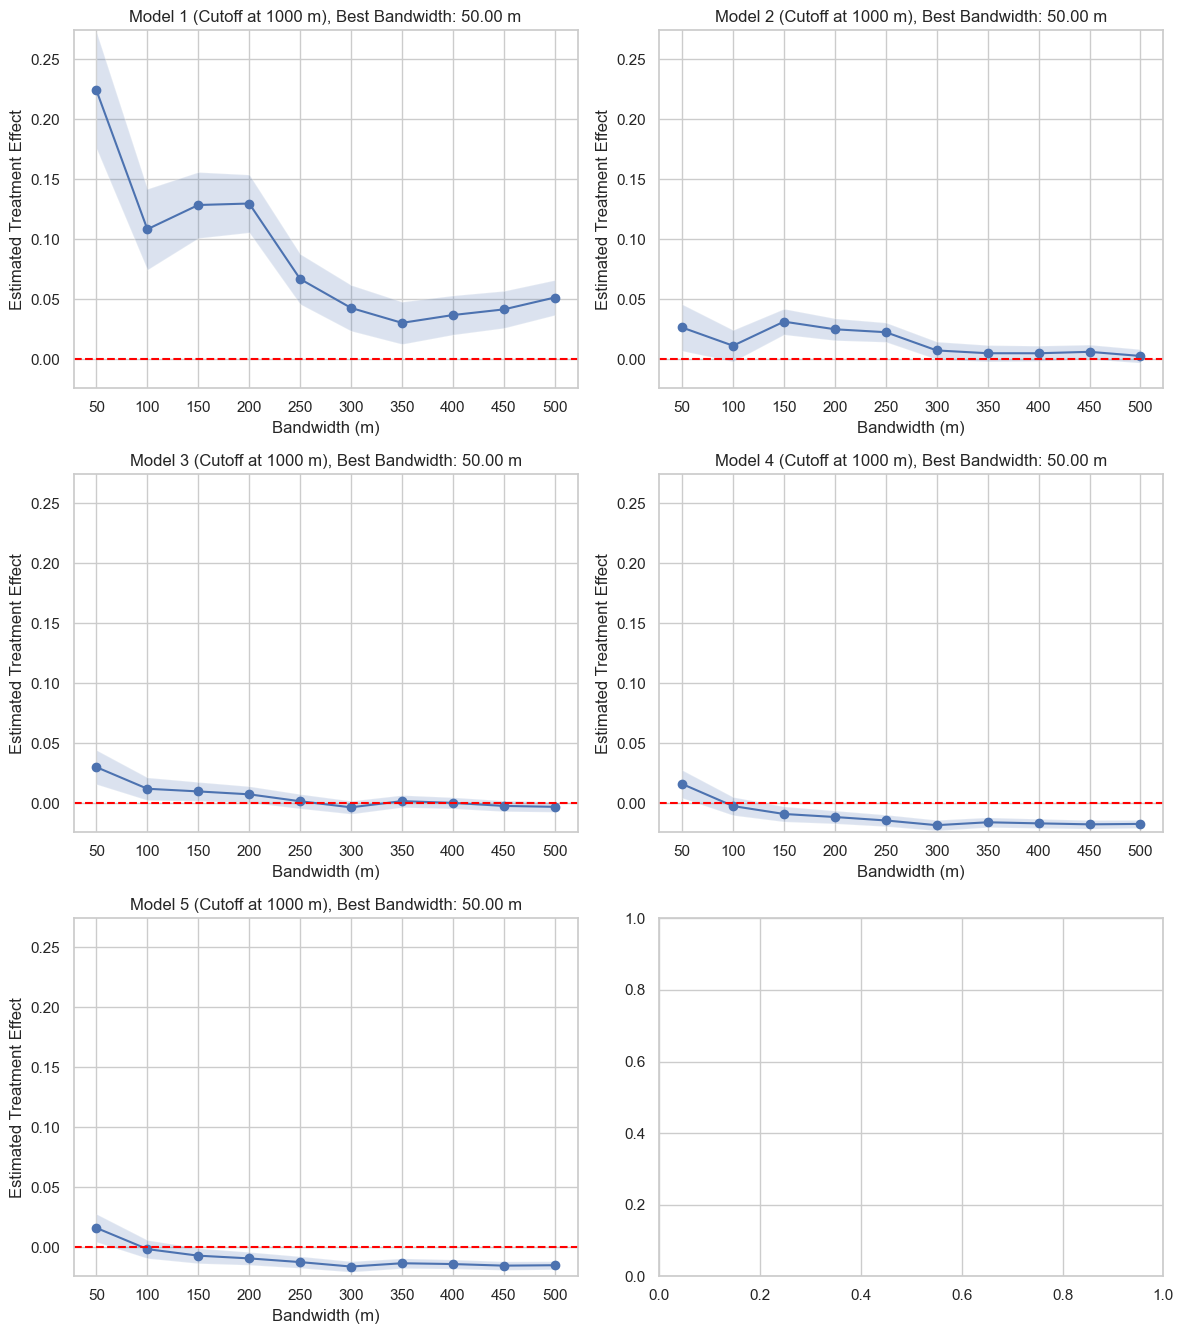

In [16]:
bandwidth_sensitivity_plot(cv_results_list_1km, 1000)

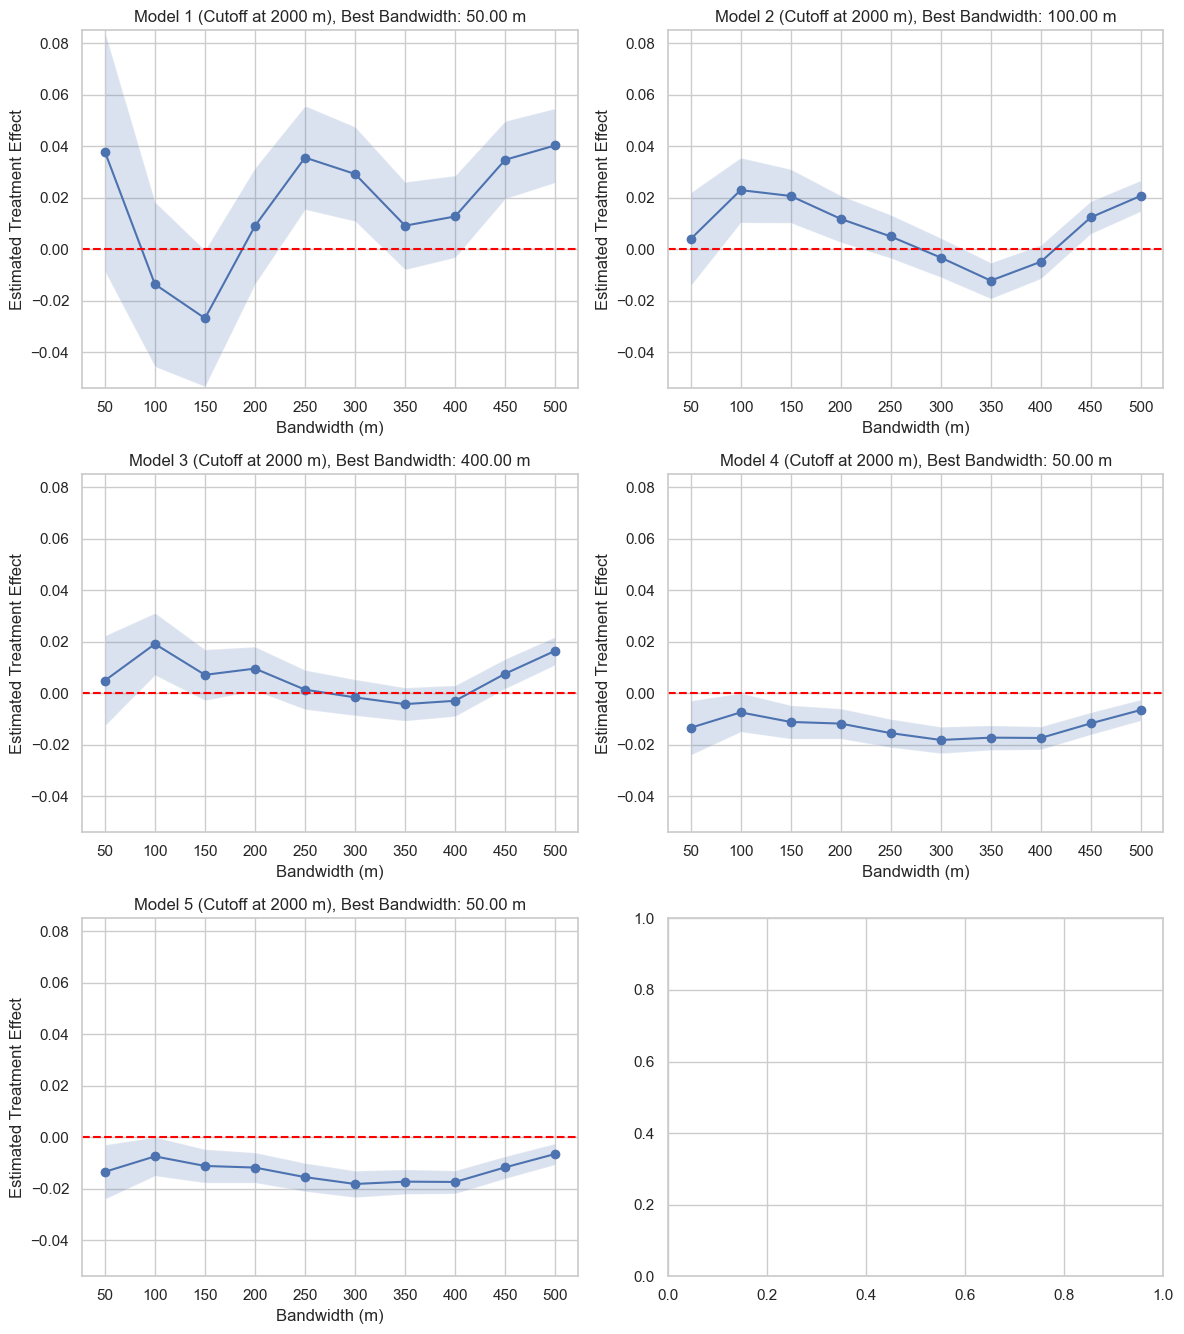

In [18]:
bandwidth_sensitivity_plot(cv_results_list_2km, 2000)

## Testing Validity of RD

### Test 1: Balance Test
from the balance tests we see that the flats near the cutoff are not exactly randomised, many variables have significant differences before and after the cutoff, so there are systemic differences in the flats near the cutoff. We can only treat our RDD as descriptive of price patterns at the school boundary rather than as causal estimates of the school proximity effect. 

In [23]:
balance_vars = [
    "floor_area_sqm",
    "remaining_lease",
    "walking_dist_mrt_m",
    "walking_dist_busstop_m",
    "walking_dist_hawker_m",
    "walking_dist_mall_m",
    "dist_cbd_m"
]

def balance_test_multi_bw(balance_vars, cutoff, bandwidths, df):
    res = []
    dfc = df.copy()

    # running and treatment variables
    dfc["running"] = dfc["nearest_tier1_primary_school_dist_m"] - cutoff
    dfc["treated"] = (dfc["nearest_tier1_primary_school_dist_m"] <= cutoff).astype(int)
    dfc["treated_running"] = dfc["treated"] * dfc["running"]

    for bw in bandwidths:
        data = dfc[dfc["running"].between(-bw, bw)].copy()
        inside = data[data["running"] <= 0]
        outside = data[data["running"] > 0]

        for var in balance_vars:
            bal_formula = f"{var} ~ treated + running + treated_running"
            bal_model = smf.ols(bal_formula, data=data).fit(cov_type="HC1")

            pval = bal_model.pvalues.get("treated", float("nan"))
            ci = bal_model.conf_int().loc["treated"]

            res.append({
                "bandwidth": bw,
                "variable": var,
                "n_obs": len(data),
                "treatment": bal_model.params.get("treated", float("nan")),
                "p_value": pval,
                "sig": (
                    "***" if pval < 0.01 else
                    "**"  if pval < 0.05 else
                    "*"   if pval < 0.10 else
                    "n.s."
                ),
                "lower": ci[0],
                "upper": ci[1],
                "inside_mean": inside[var].mean(),
                "outside_mean": outside[var].mean(),
                "diff": inside[var].mean() - outside[var].mean()
            })

    return pd.DataFrame(res)

In [29]:
def plot_balance_sensitivity(balance_results, ncols=2, figsize_per_row=4):
    vars_list = balance_results["variable"].unique()
    nvars = len(vars_list)
    nrows = math.ceil(nvars / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(7 * ncols, figsize_per_row * nrows)
    )

    # make axes always iterable
    if nrows == 1 and ncols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, var in enumerate(vars_list):
        ax = axes[i]
        temp = balance_results[balance_results["variable"] == var].copy()
        temp = temp.sort_values("bandwidth")

        coef = temp["treatment"]
        lower = temp["lower"]
        upper = temp["upper"]
        yerr = [coef - lower, upper - coef]

        ax.errorbar(
            temp["bandwidth"],
            coef,
            yerr=yerr,
            fmt="o-",
            capsize=4
        )
        ax.axhline(0, linestyle="--")
        ax.set_title(var)
        ax.set_xlabel("Bandwidth")
        ax.set_ylabel("Coefficient on treated")
        ax.set_xticks(temp["bandwidth"])

    # remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

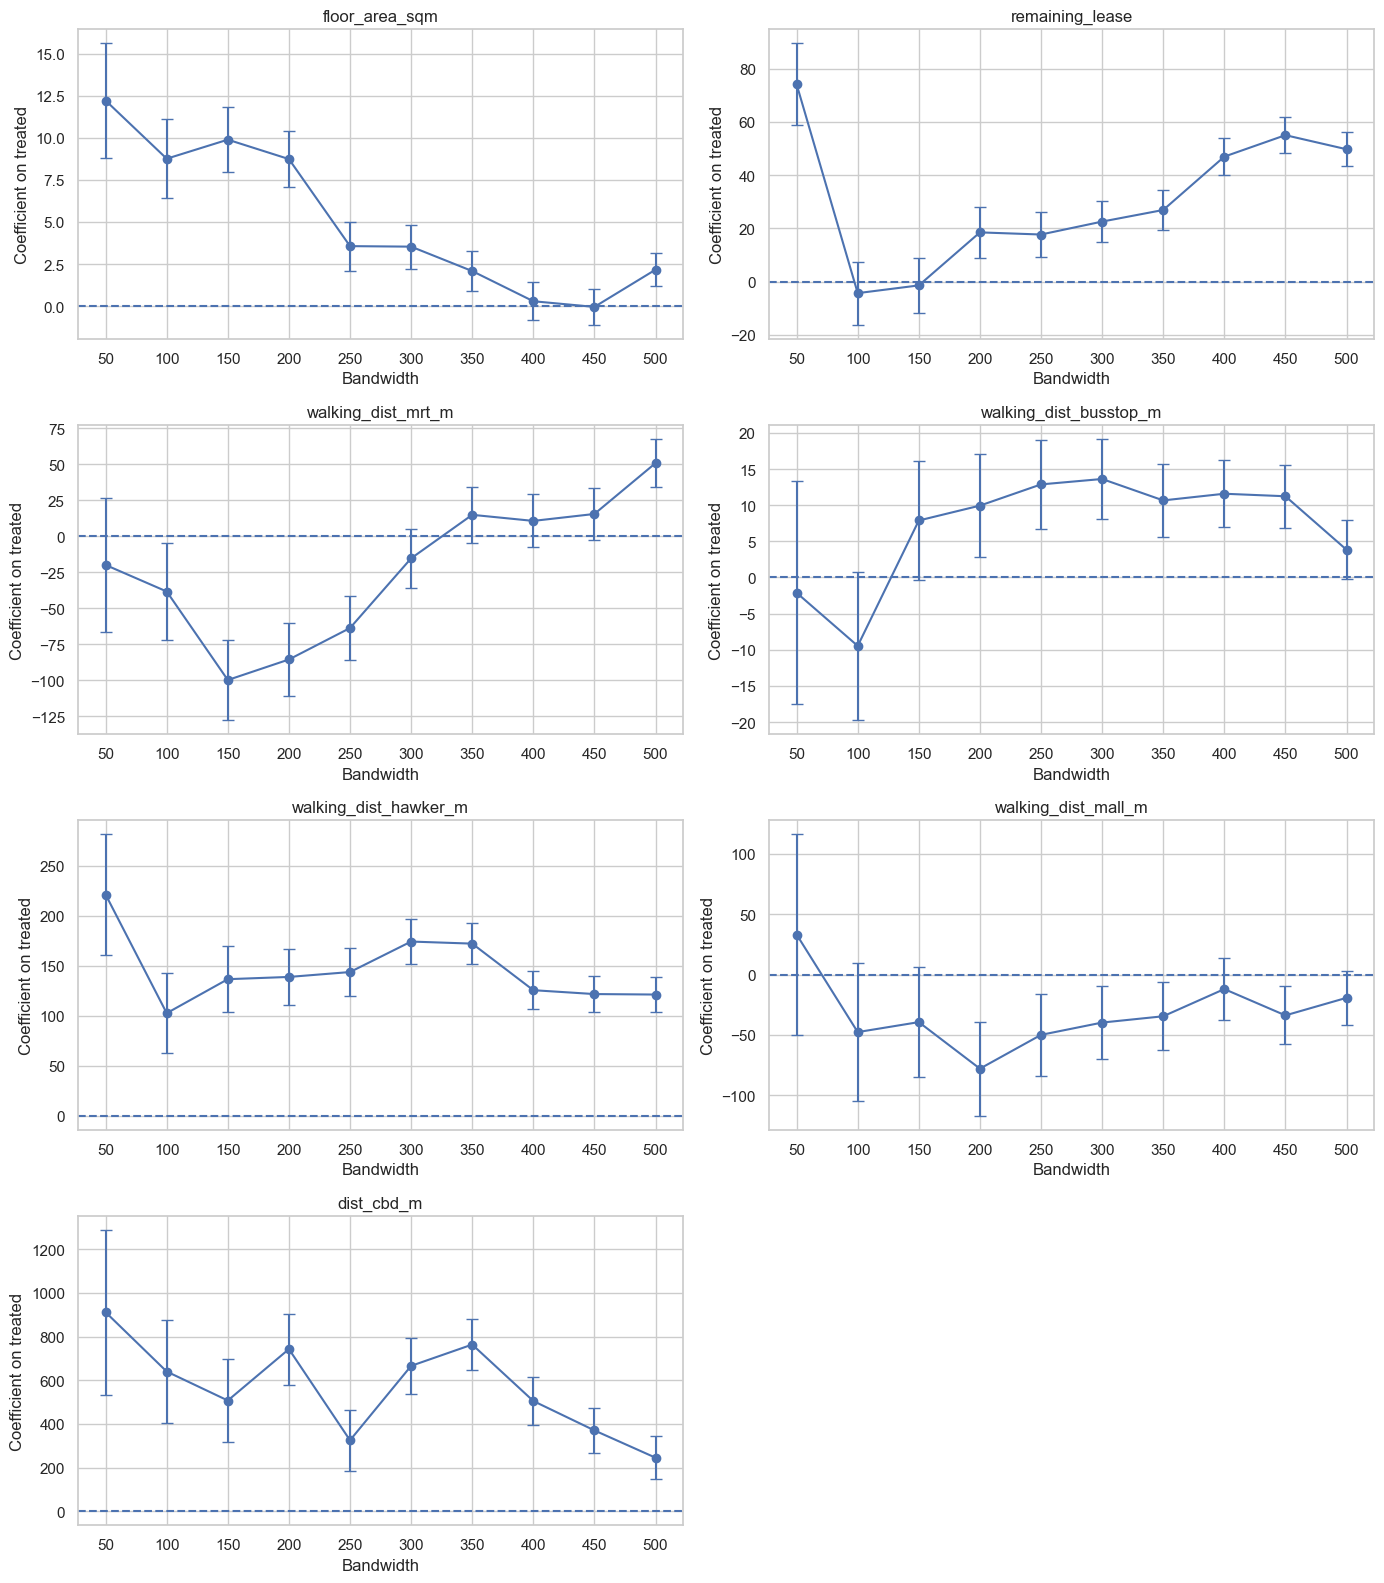

In [30]:
balance_1km = balance_test_multi_bw(balance_vars, 1000, bandwidths, df_rdd)
plot_balance_sensitivity(balance_1km, ncols=2)

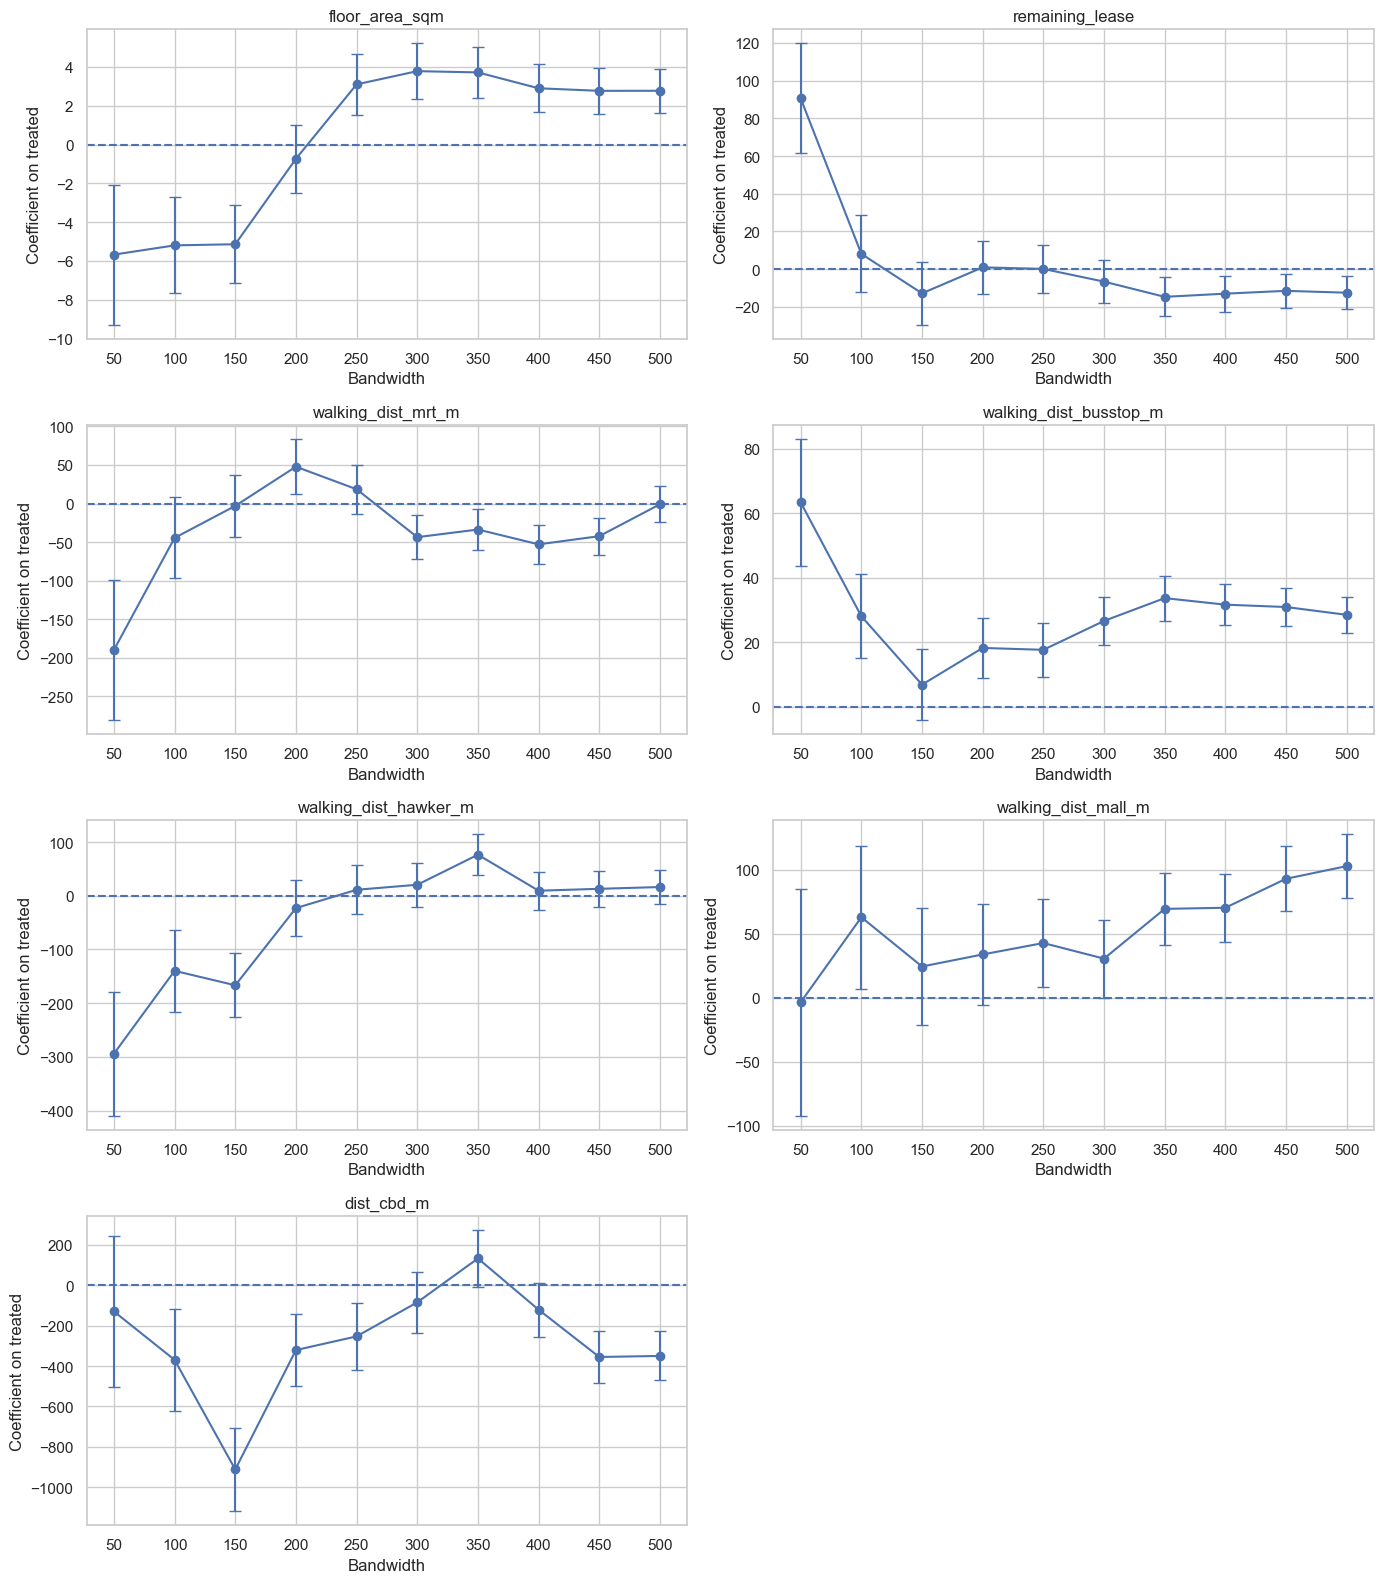

In [31]:
balance_2km = balance_test_multi_bw(balance_vars, 2000, bandwidths, df_rdd)
plot_balance_sensitivity(balance_2km, ncols=2)


In [19]:
def plot_balance_tests(balance_vars, cutoff, band, df): 
    dfc = df.copy()
    # determine the running and treatment variables based on cutoff
    dfc["running"] = dfc["nearest_tier1_primary_school_dist_m"] - cutoff 
    dfc["treated"] = (dfc["nearest_tier1_primary_school_dist_m"] <= cutoff).astype(int)
    dfc["treated_running"] = dfc["treated"] * dfc["running"] #interaction variable 
    data = dfc[dfc["running"].between(-band, band)]
    inside = data[data["running"] <= 0].copy()
    outside = data[data["running"] > 0].copy()
    fig, axes = plt.subplots(5, 2, figsize=(15, 25)) 
    axes = axes.flatten() 

    for i, col in enumerate(balance_vars): 
        ax = axes[i]

        bal_formula = f"{col} ~ treated + running + treated_running"
        bal_model = smf.ols(bal_formula, data=data).fit(cov_type="HC1")
    
        jump = bal_model.params.get("treated", np.nan)
        pval = bal_model.pvalues.get("treated", np.nan)

        sns.scatterplot(data = data, y = col, x = "running", ax=ax, marker='.') 
        if len(inside) > 1:
            left_model = smf.ols(f"{col} ~ running", data=inside).fit(cov_type="HC1")
            x_left = np.linspace(inside["running"].min(), 0, 100)
            y_left = left_model.predict(pd.DataFrame({"running": x_left}))
            ax.plot(x_left, y_left, linewidth=2)
    
        if len(outside) > 1:
            right_model = smf.ols(f"{col} ~ running", data=outside).fit(cov_type="HC1")
            x_right = np.linspace(0, outside["running"].max(), 100)
            y_right = right_model.predict(pd.DataFrame({"running": x_right}))
            ax.plot(x_right, y_right, linewidth=2)
    
        # 5. Add cutoff line
        ax.axvline(0, linestyle="--", color="black", alpha=0.8)

        # 6. Titles and labels
        ax.set_title(f"{col}\nJump = {jump:.3f}, p-value = {pval:.3f}")
        ax.set_xlabel("Distance to 1km cutoff (metres)")
        ax.set_ylabel(col)

    plt.tight_layout() 
    plt.show()

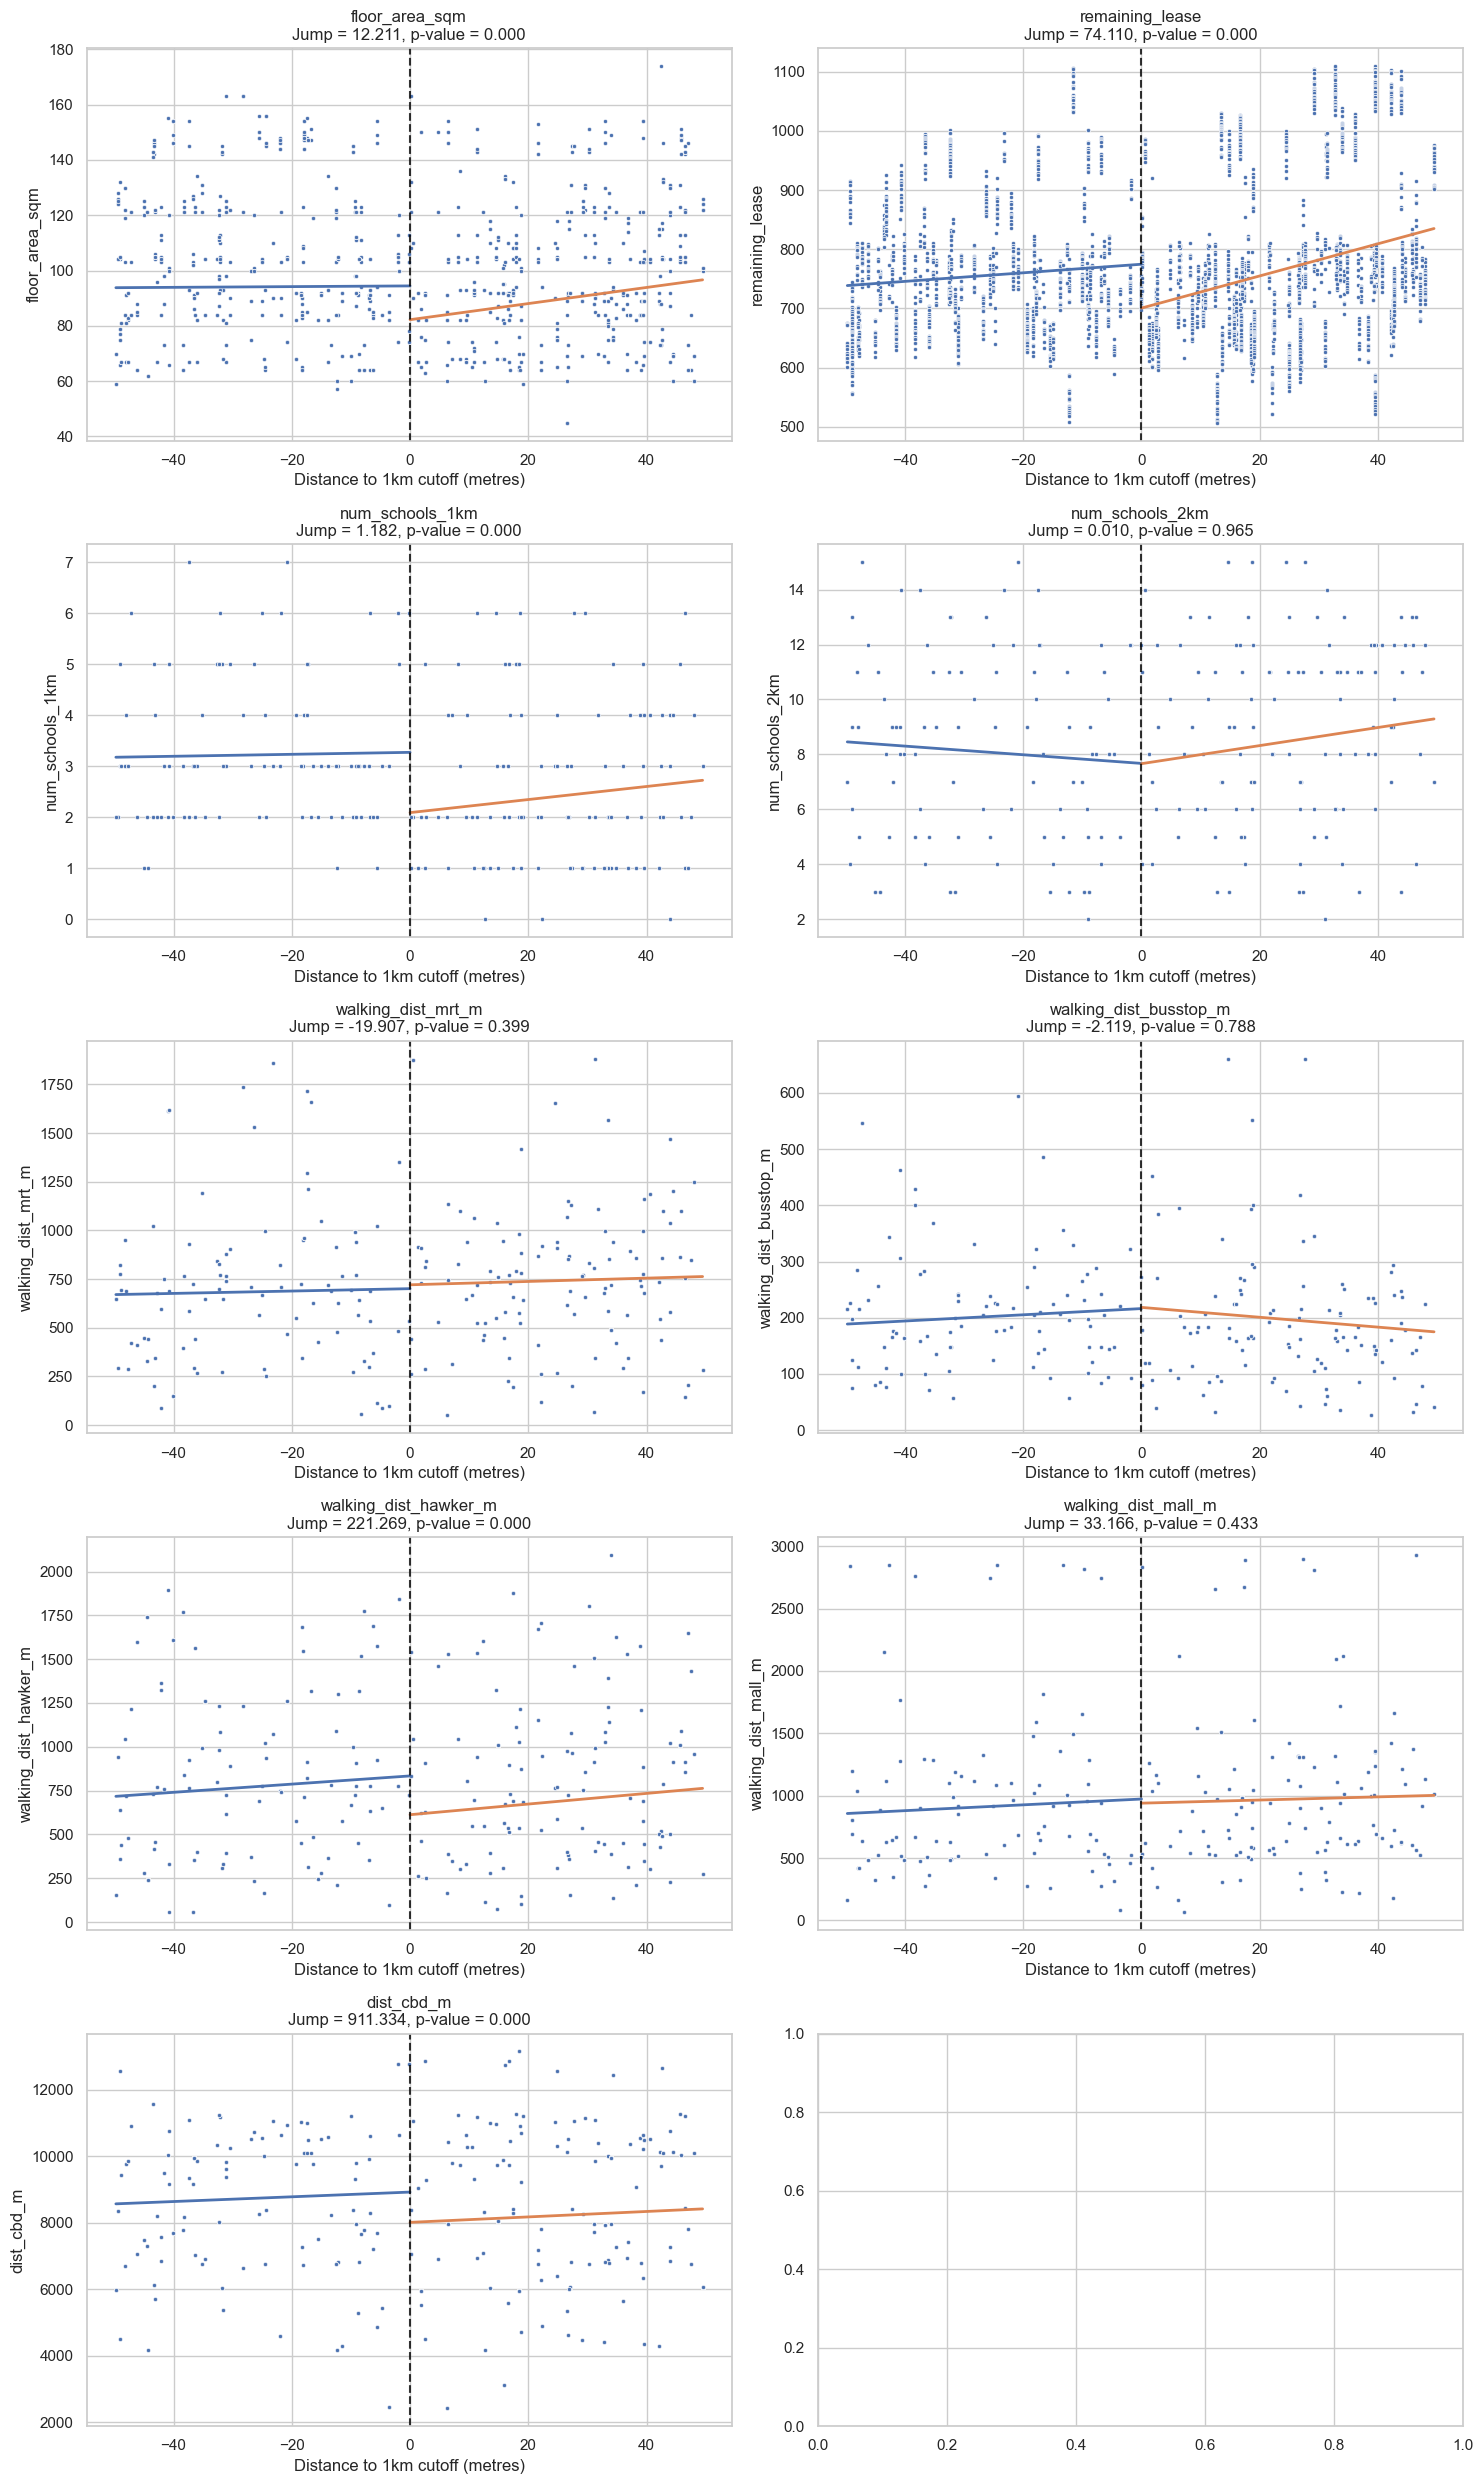

In [20]:
plot_balance_tests(balance_vars, 1000, 50, df_rdd)

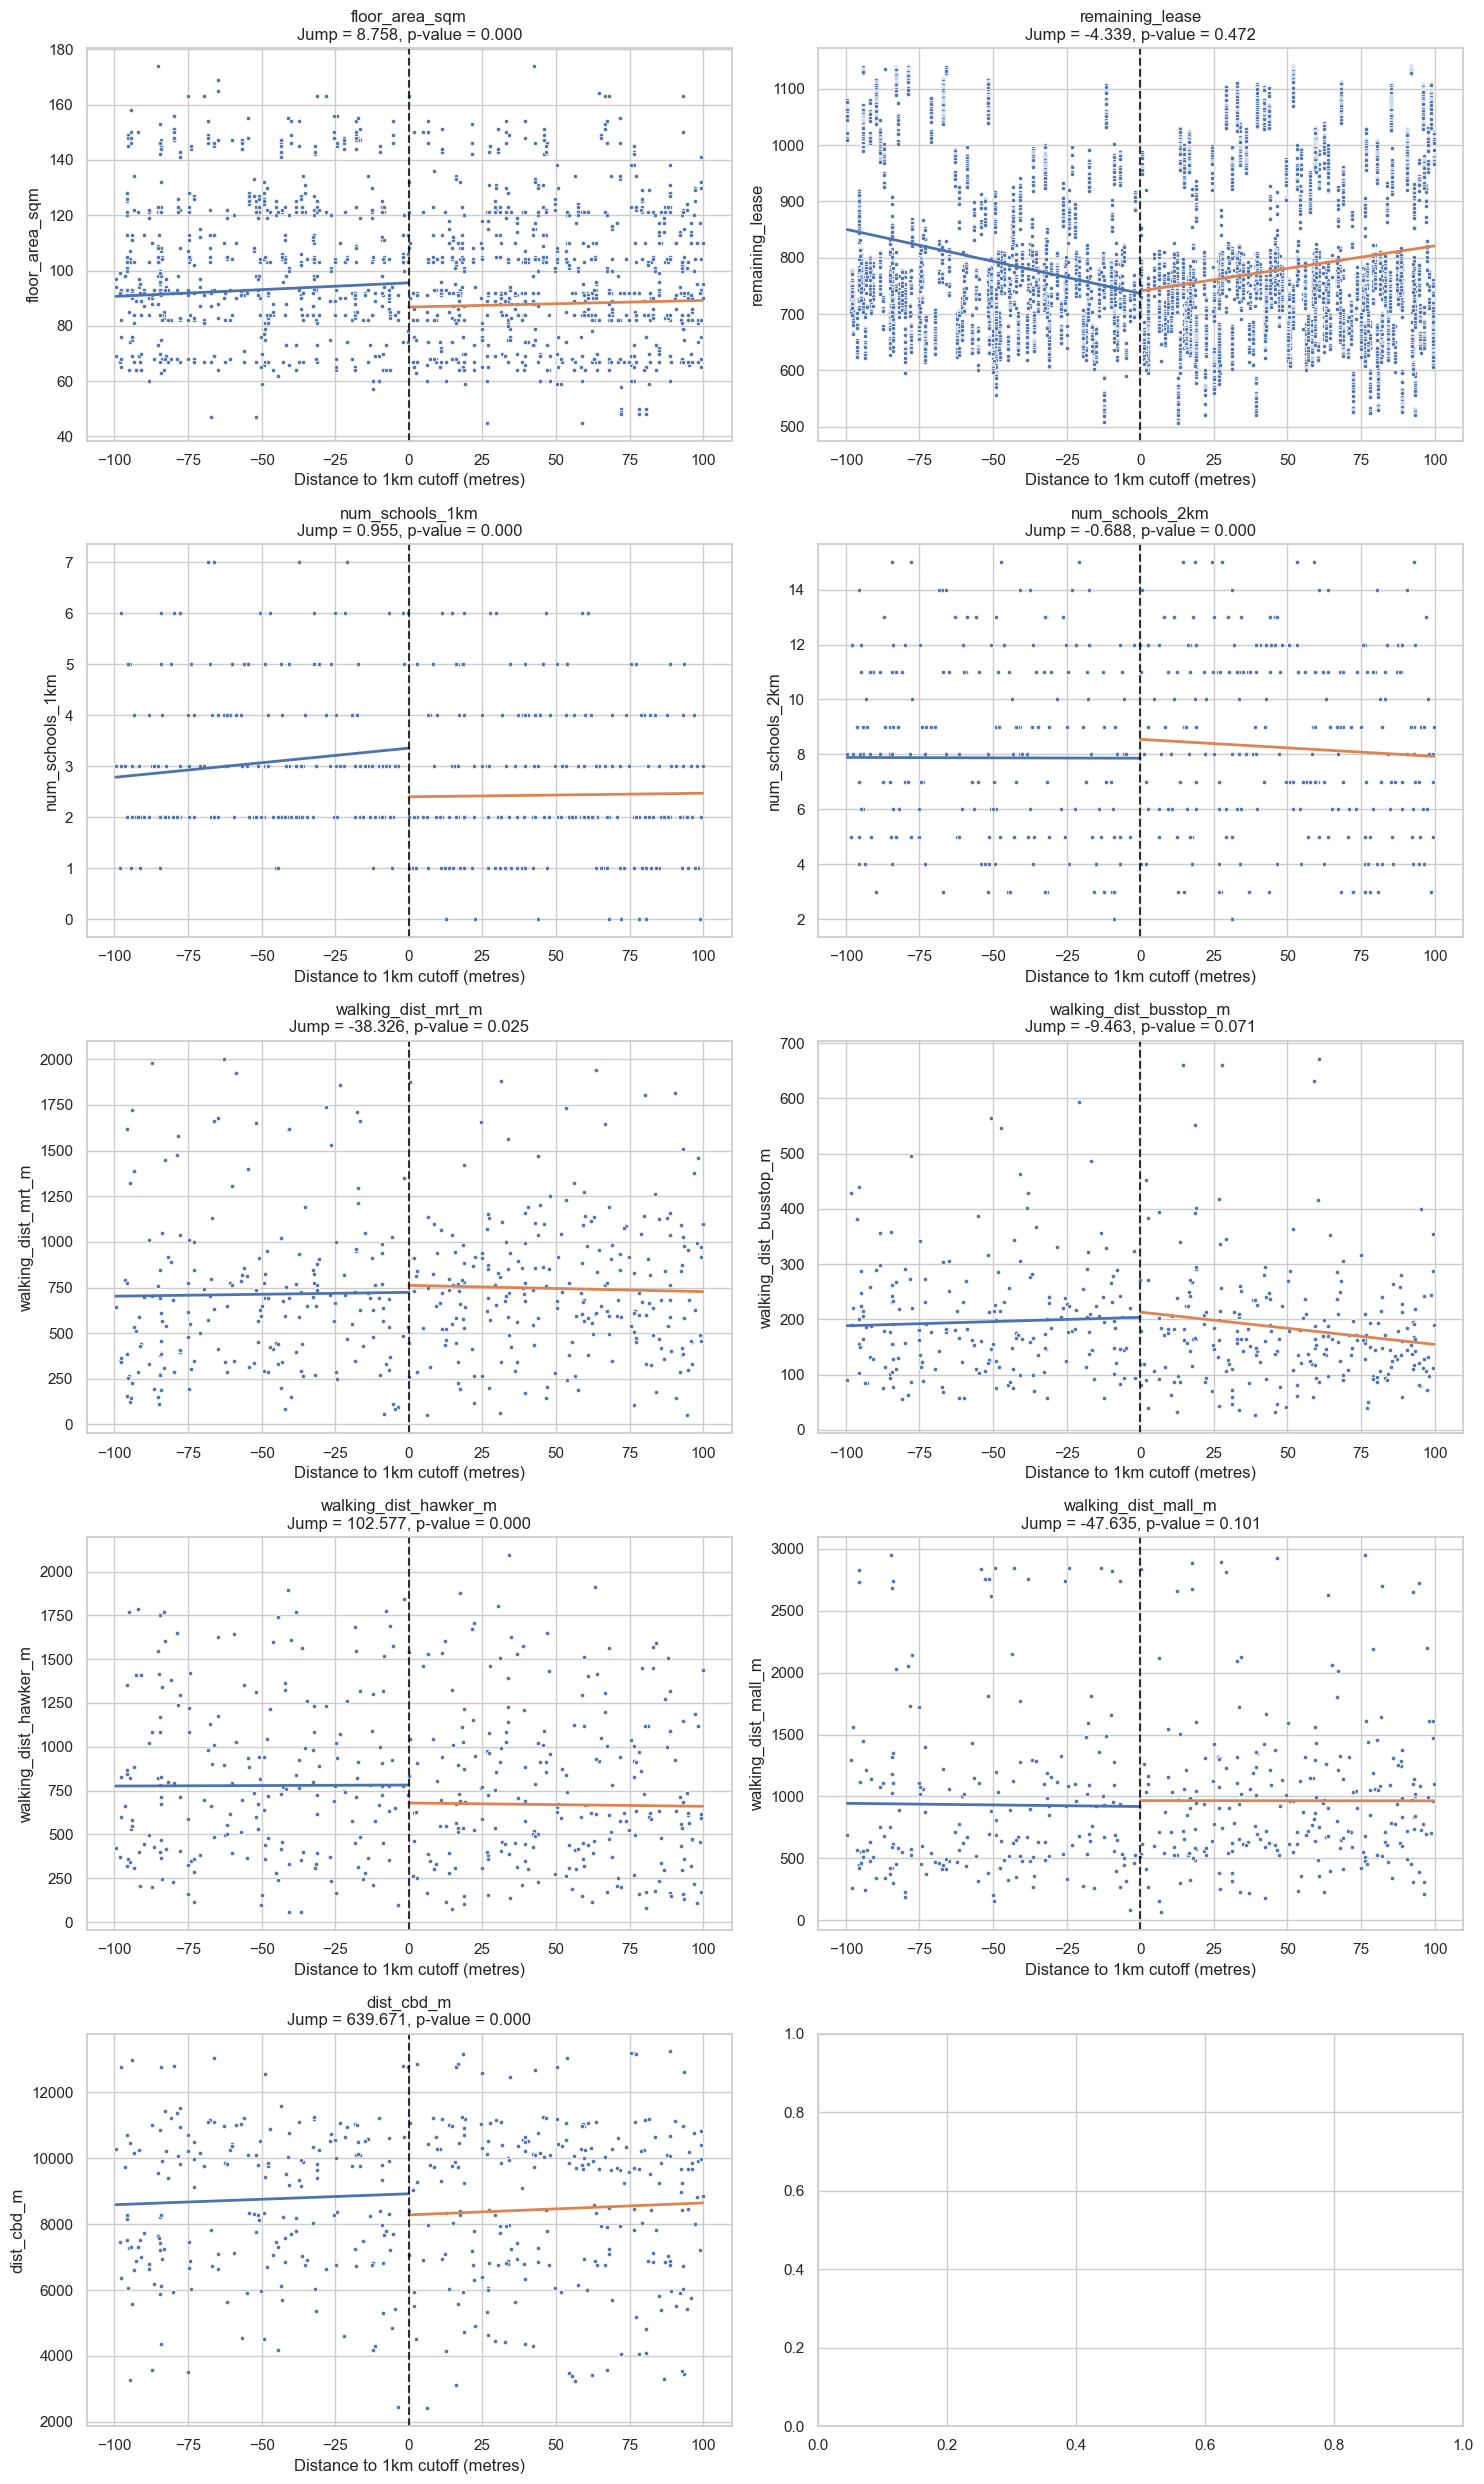

In [21]:
plot_balance_tests(balance_vars, 1000, 100, df_rdd)

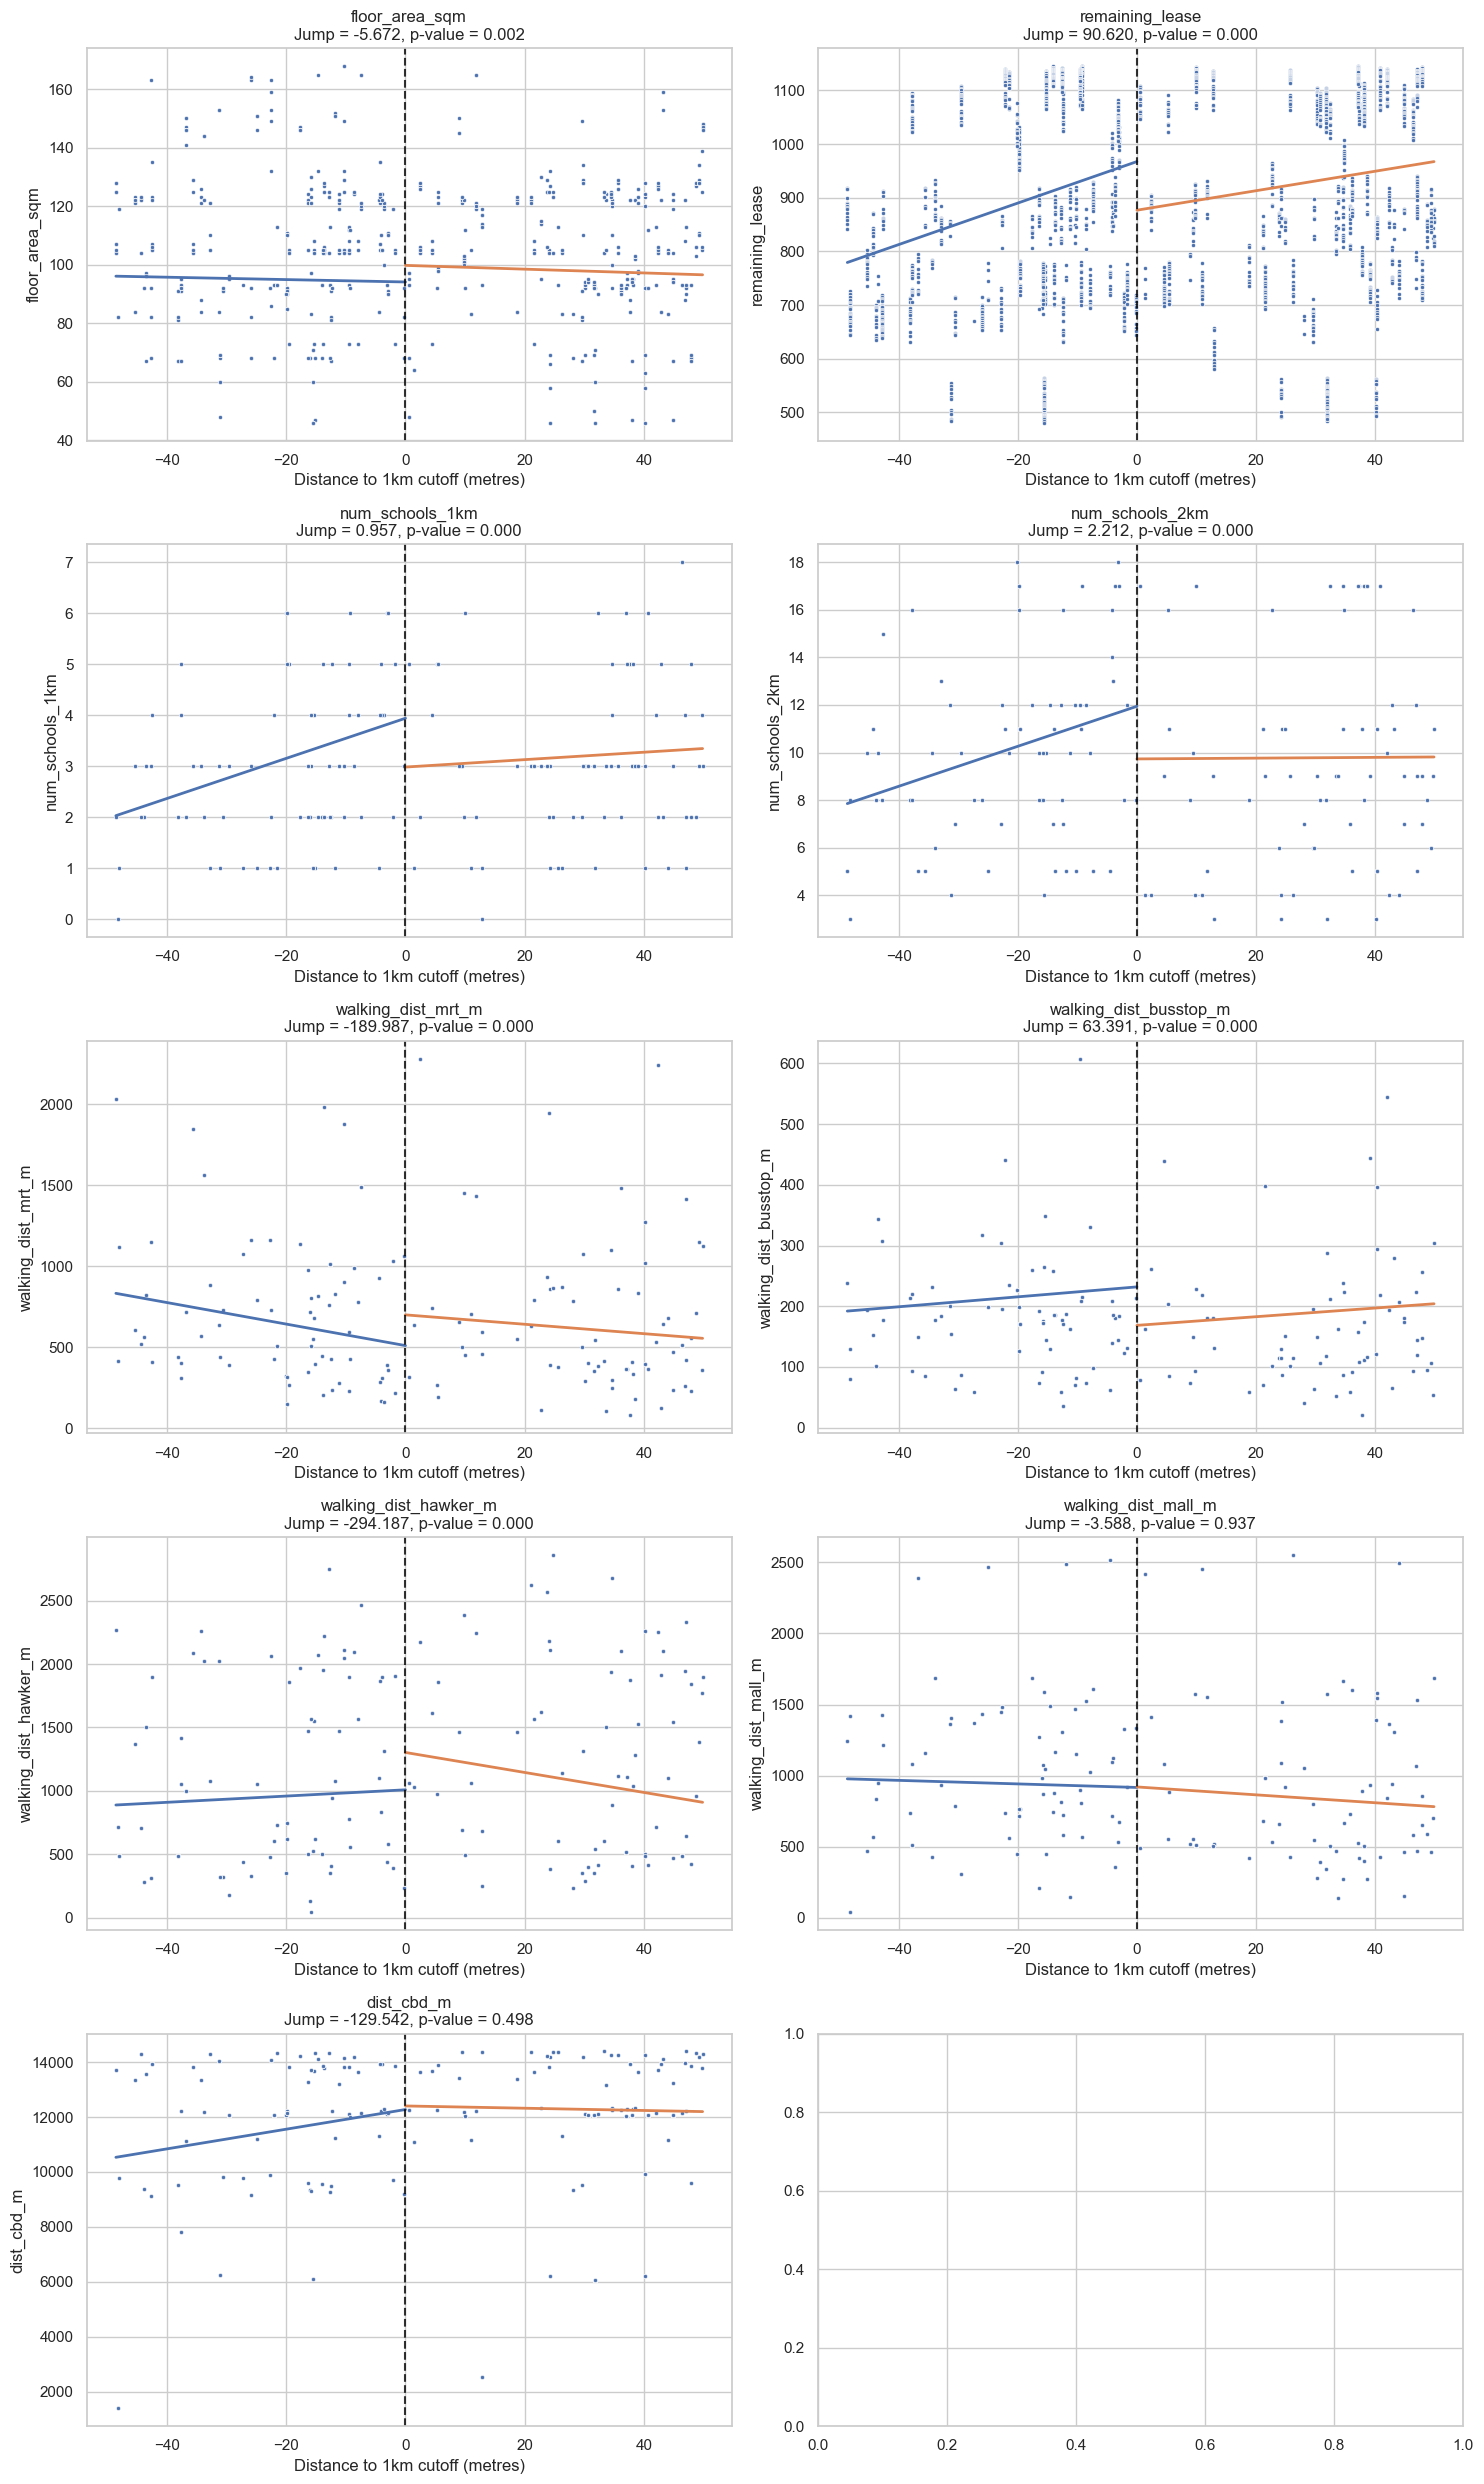

In [22]:
plot_balance_tests(balance_vars, 2000, 50, df_rdd)

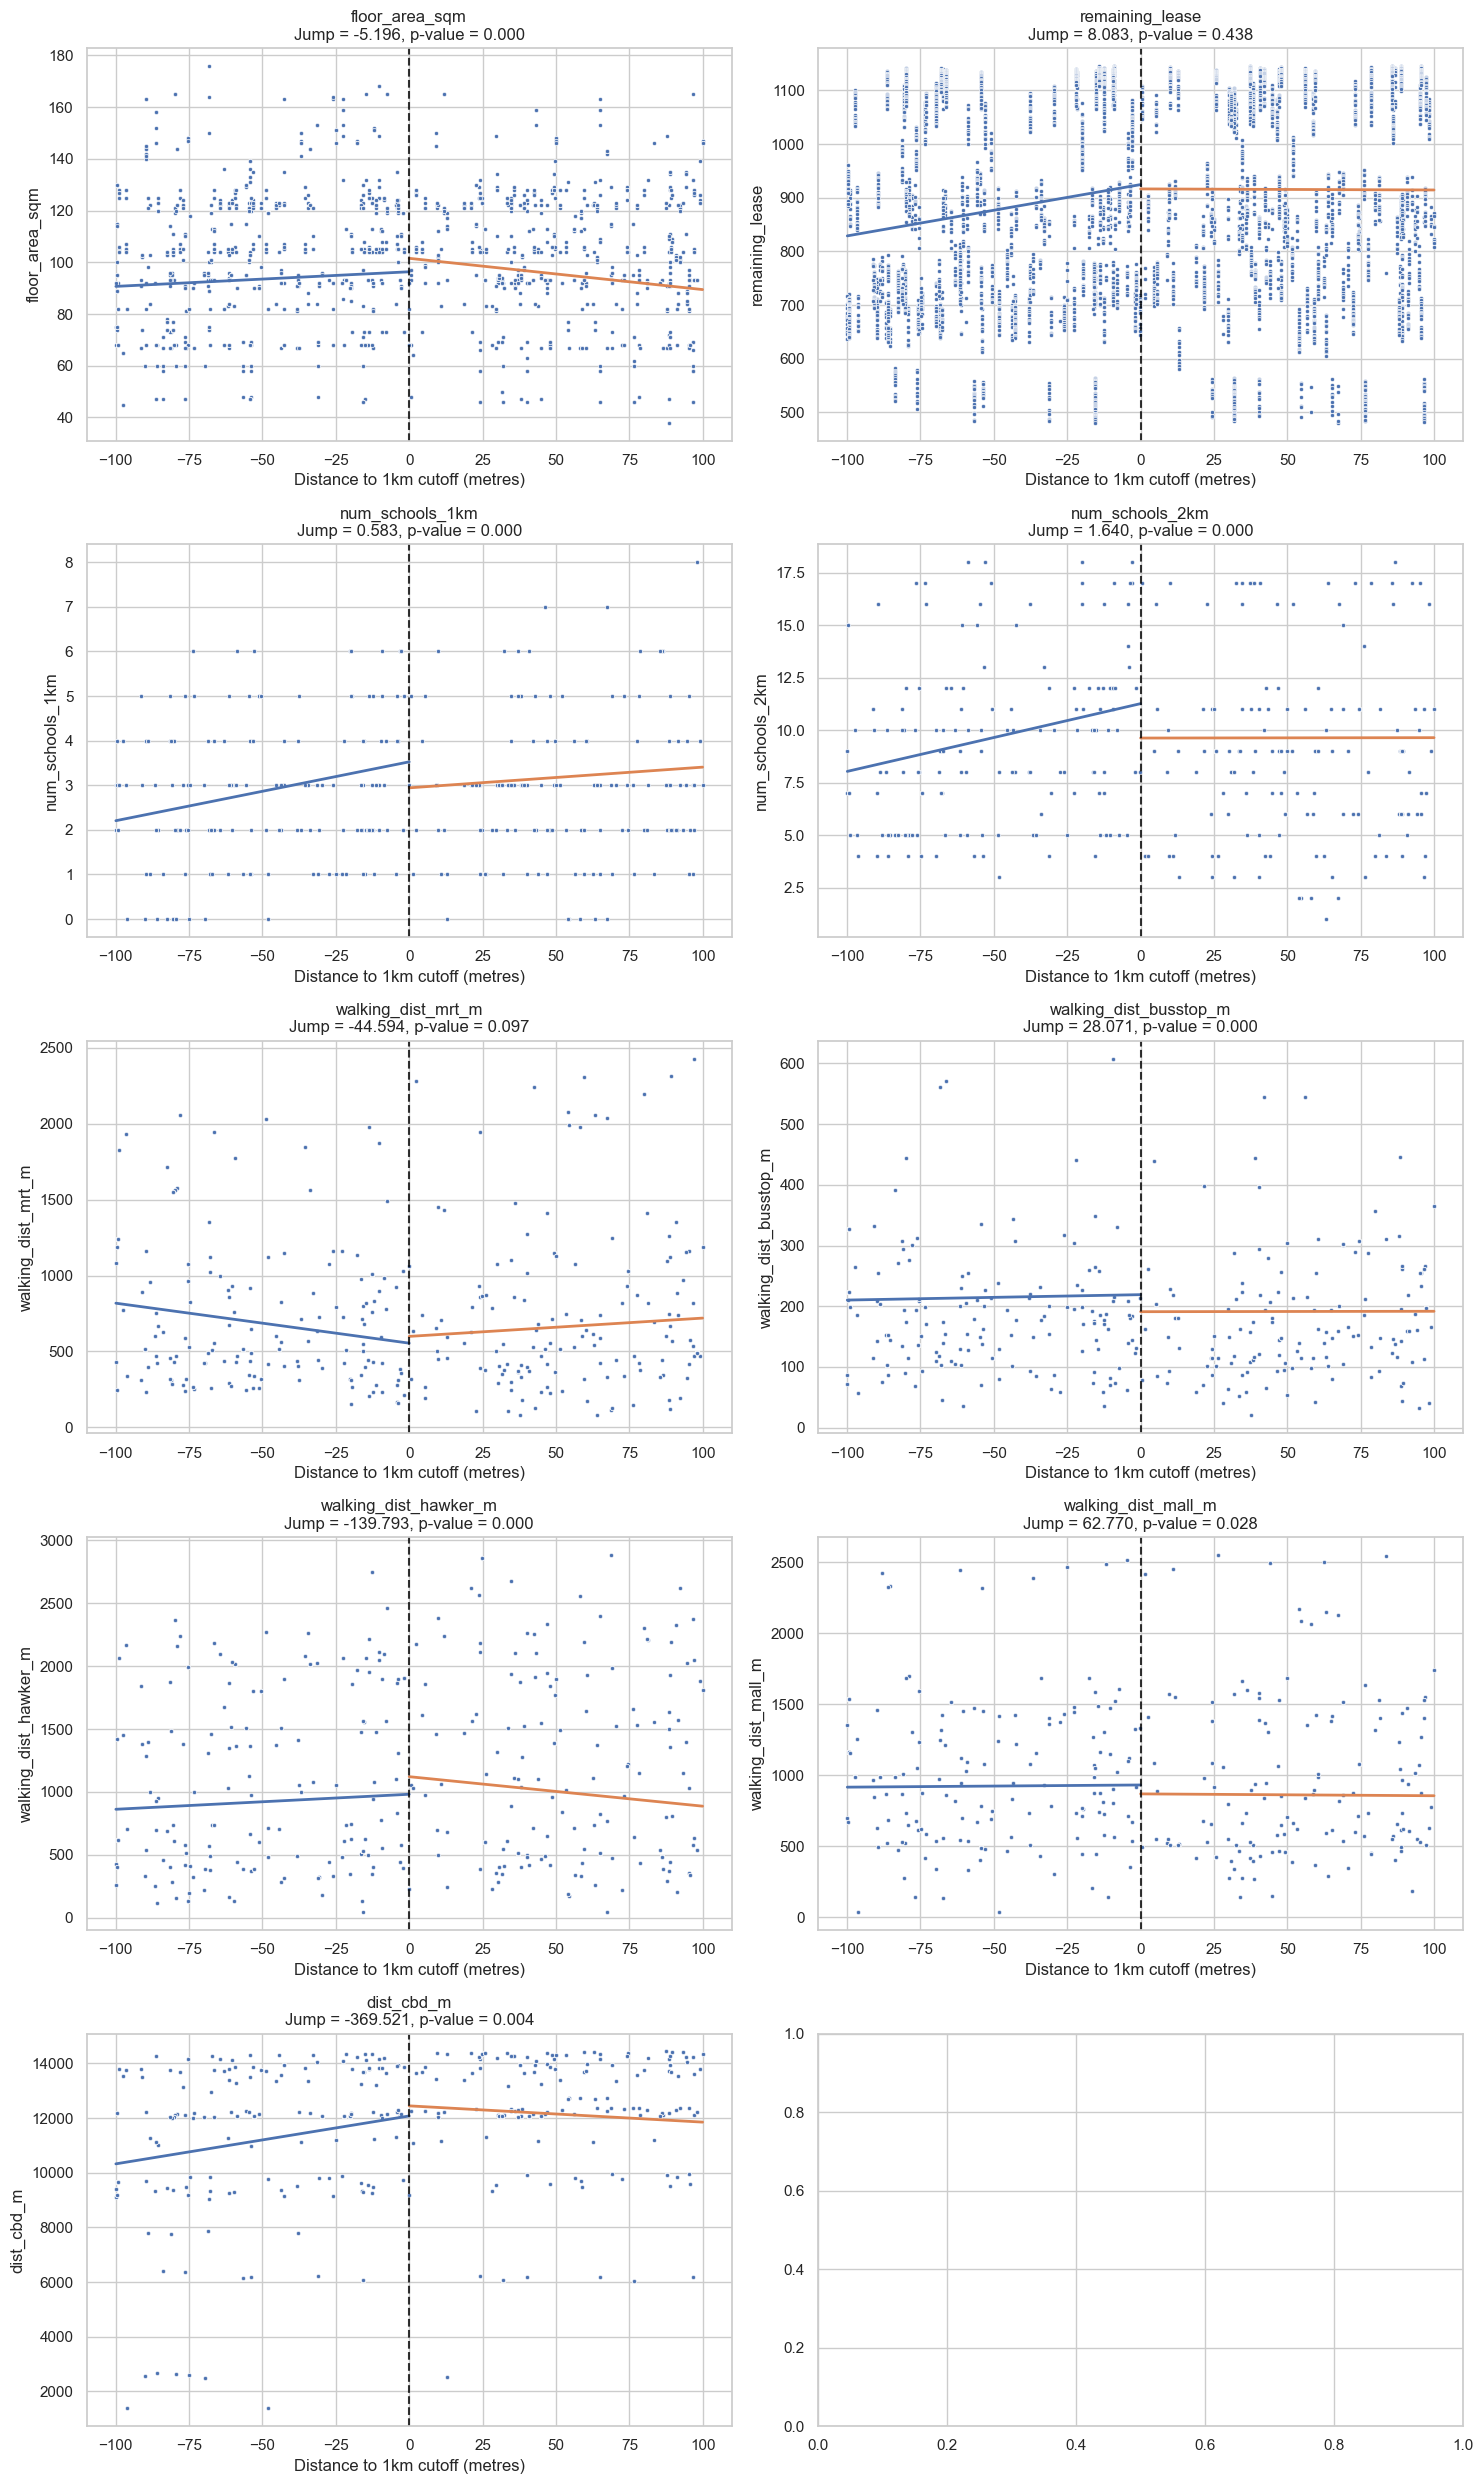

In [23]:
plot_balance_tests(balance_vars, 2000, 100, df_rdd)

### Test 2: McCrary Density Test
possible manipulation for 1km,the density of observations changes discontinuously, more flats for resale just below the 1km cutoff, people specifically buy flats there, bunching of density.
around 2km the density looks smooth

In [115]:
X = df_rdd["nearest_tier1_primary_school_dist_m"].values

def mccrary_test(X, cutoff, nbins=30):
    X = np.asarray(X, dtype=float) 
    n = len(X)

    left  = X[X < cutoff]
    right = X[X >= cutoff]

    # Silverman's rule-of-thumb bandwidth
    h = 1.06 * X.std() * n ** (-1/5)
    print(h)

    # Bin the data
    bins = np.linspace(X.min(), X.max(), nbins + 1)
    bin_width = bins[1] - bins[0]
    counts, _ = np.histogram(X, bins=bins)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Separate bins left and right of cutoff
    left_mask  = bin_centers < cutoff
    right_mask = bin_centers >= cutoff

    x_left   = bin_centers[left_mask]
    y_left   = counts[left_mask] / (n * bin_width)
    x_right  = bin_centers[right_mask]
    y_right  = counts[right_mask] / (n * bin_width)

    # Fit linear regression on each side to estimate density at cutoff
    def fit_at_cutoff(x, y, cutoff):
        x_c = x - cutoff  # center at cutoff
        A = np.column_stack([np.ones_like(x_c), x_c])
        coeffs, residuals, _, _ = np.linalg.lstsq(A, y, rcond=None)
        intercept = coeffs[0]
        y_hat = A @ coeffs
        se = np.sqrt(np.sum((y - y_hat) ** 2) / max(len(y) - 2, 1))
        se_intercept = se * np.sqrt(np.mean(x_c**2) / (len(x_c) * np.var(x_c)))
        return intercept, se_intercept

    f_left,  se_left  = fit_at_cutoff(x_left,  y_left,  cutoff)
    f_right, se_right = fit_at_cutoff(x_right, y_right, cutoff)

    # z-test for discontinuity
    diff = f_right - f_left
    se_diff = np.sqrt(se_left**2 + se_right**2)
    z_stat = diff / se_diff
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

    return {
        "f_left":   f_left,
        "f_right":  f_right,
        "diff":     diff,
        "z_stat":   z_stat,
        "p_value":  p_value,
        "bandwidth": h
    }

In [116]:
result_1km = mccrary_test(X, 1000)

print("=" * 40)
print("      McCrary Density Test Results")
print("=" * 40)
print(f"  Density left of cutoff:  {result_1km['f_left']:.4f}")
print(f"  Density right of cutoff: {result_1km['f_right']:.4f}")
print(f"  Difference:              {result_1km['diff']:.4f}")
print(f"  Z-statistic:             {result_1km['z_stat']:.4f}")
print(f"  P-value:                 {result_1km['p_value']:.4f}")
print(f"  Bandwidth:               {result_1km['bandwidth']:.4f}")
print("=" * 40)
if result_1km['p_value'] > 0.05:
    print("  No evidence of manipulation (p > 0.05)")
else:
    print("  Possible manipulation detected (p < 0.05)")

247.9644839220479
      McCrary Density Test Results
  Density left of cutoff:  0.0002
  Density right of cutoff: 0.0002
  Difference:              -0.0001
  Z-statistic:             -2.1856
  P-value:                 0.0288
  Bandwidth:               247.9645
  Possible manipulation detected (p < 0.05)


In [117]:
result_2km = mccrary_test(X, 2000)

print("=" * 40)
print("      McCrary Density Test Results")
print("=" * 40)
print(f"  Density left of cutoff:  {result_2km['f_left']:.4f}")
print(f"  Density right of cutoff: {result_2km['f_right']:.4f}")
print(f"  Difference:              {result_2km['diff']:.4f}")
print(f"  Z-statistic:             {result_2km['z_stat']:.4f}")
print(f"  P-value:                 {result_2km['p_value']:.4f}")
print(f"  Bandwidth:               {result_2km['bandwidth']:.4f}")
print("=" * 40)
if result_2km['p_value'] > 0.05:
    print("  No evidence of manipulation (p > 0.05)")
else:
    print("  Possible manipulation detected (p < 0.05)")

247.9644839220479
      McCrary Density Test Results
  Density left of cutoff:  0.0002
  Density right of cutoff: 0.0001
  Difference:              -0.0001
  Z-statistic:             -1.8854
  P-value:                 0.0594
  Bandwidth:               247.9645
  No evidence of manipulation (p > 0.05)


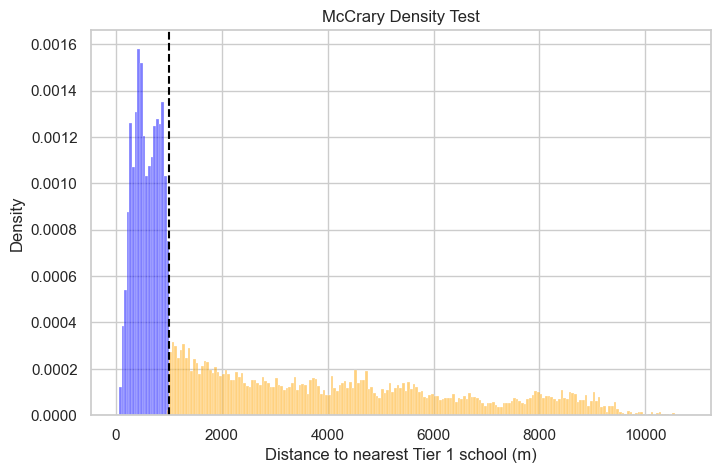

In [ ]:
def mccrary_plot(df, running, cutoff=1000, binwidth=50):

    x = df[running]

    bins = np.arange(x.min(), x.max(), binwidth)

    plt.figure(figsize=(8,5))

    sns.histplot(x[x < cutoff], bins=bins, stat="density", color="blue", alpha=0.5)
    sns.histplot(x[x >= cutoff], bins=bins, stat="density", color="orange", alpha=0.5)

    plt.axvline(cutoff, linestyle="--", color="black")

    plt.xlabel("Distance to nearest Tier 1 school (m)")
    plt.ylabel("Density")
    plt.title("McCrary Density Test")

    plt.show()

mccrary_plot(df_rdd, "nearest_tier1_primary_school_dist_m", 1000)

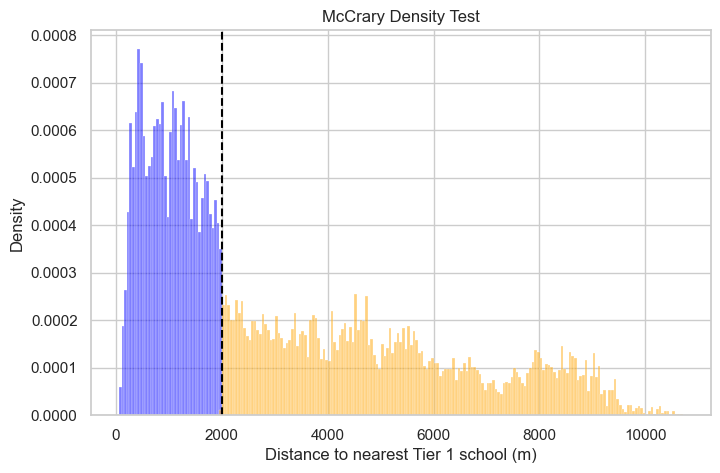

In [56]:
mccrary_plot(df_rdd, "nearest_tier1_primary_school_dist_m", 2000)

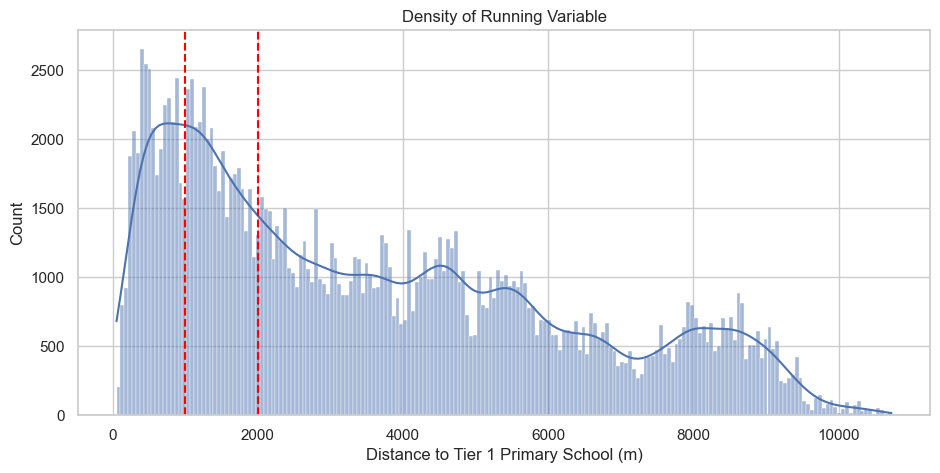

In [110]:
# testing for discontinuity in the density of the running variable at the cutoff
running = df_rdd["nearest_tier1_primary_school_dist_m"]

plt.figure(figsize=(11,5))
sns.histplot(running, bins=200, kde=True)
plt.axvline(1000, linestyle="--", color="red")
plt.axvline(2000, linestyle="--", color="red")
plt.xlabel("Distance to Tier 1 Primary School (m)")
plt.title("Density of Running Variable")
plt.show()

### Test 3: Placebo Cutoffs
can see the placebo cutoffs are also very erratic and unstable, not all are near 0. shows that there is alot of variation of distribution of flats vs distance to good schools

In [67]:
np.random.seed(11)
placebo_cutoffs = np.random.choice(range(100, 3000, 10), size=10, replace=False)
placebo_cutoffs

array([1930,  620, 1870, 1130,  220, 1530, 1540, 2730, 2960,  120])

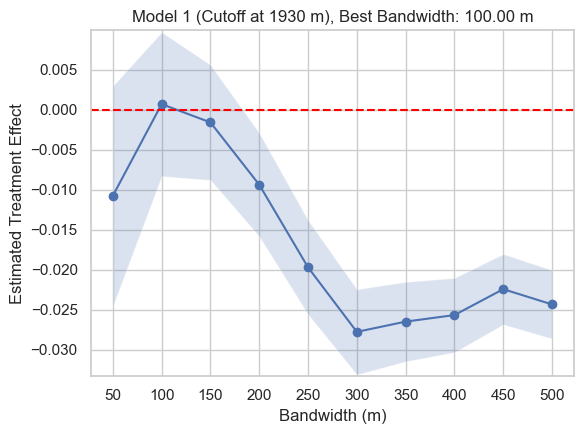

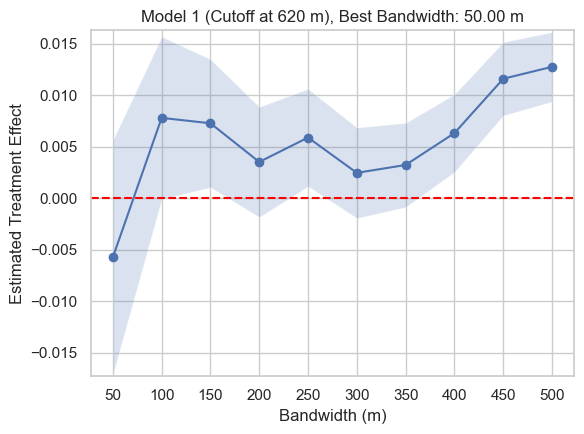

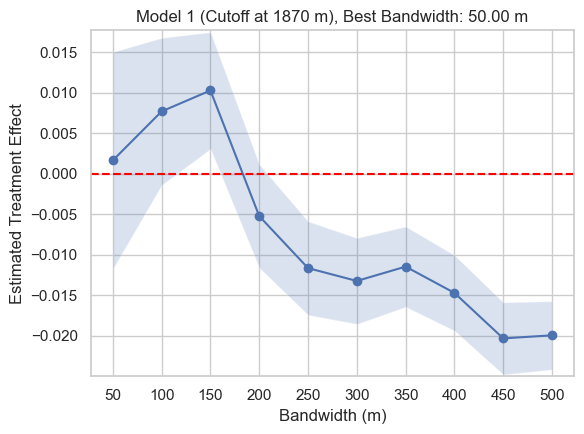

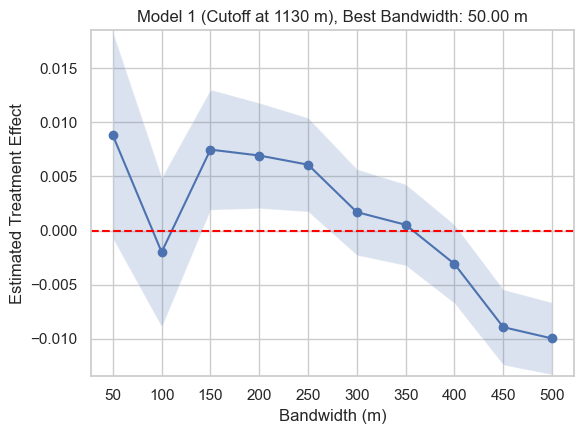

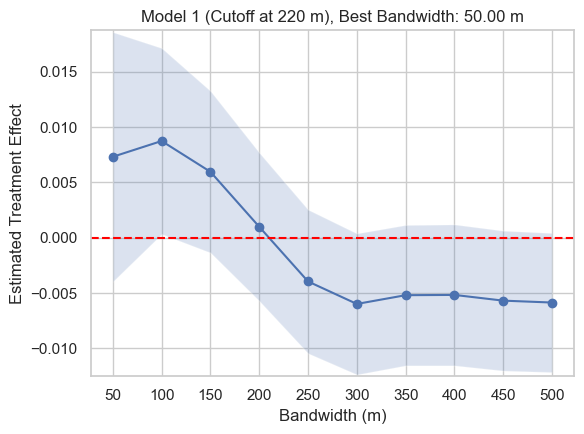

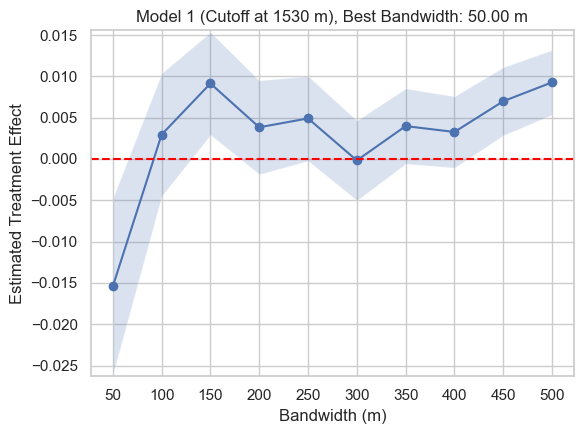

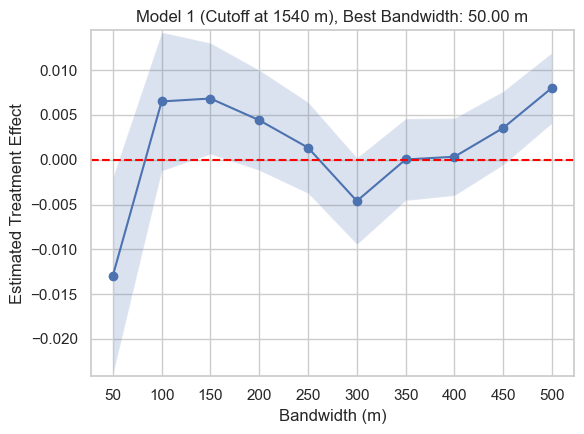

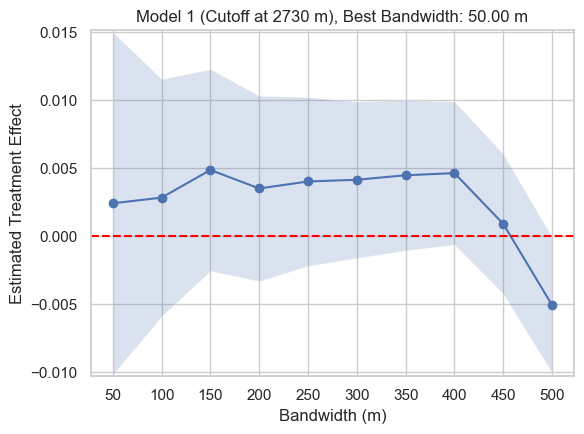

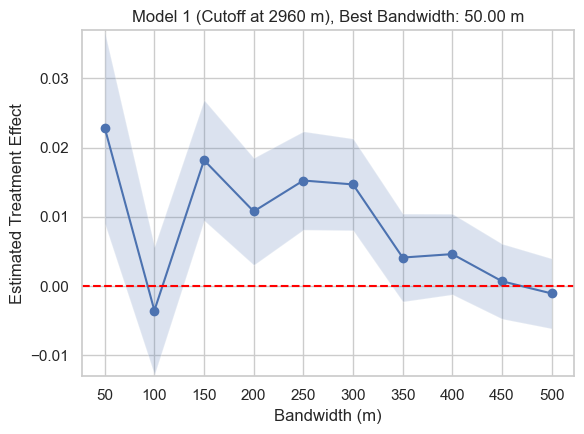

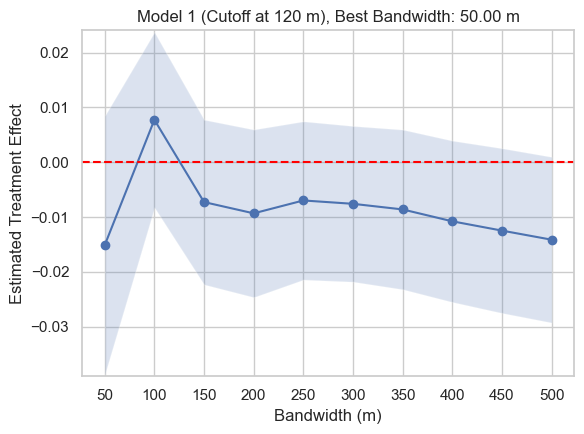

In [73]:
# try different placebo cutoffs to check if they are insignificant
for cutoffs in placebo_cutoffs:
    model = cv_mse(f5a, df_rdd, kf, bandwidths, cutoffs)
    bandwidth_sensitivity_plot([model], cutoffs, 1)
